# Prediksi Minat Pembelian Pengunjung Website E-Commerce Menggunakan Machine Learning

Proyek ini bertujuan untuk memprediksi apakah pengunjung website e-commerce akan melakukan pembelian atau tidak berdasarkan perilaku kunjungan pada website.

Jenis proyek ini termasuk ke dalam Machine Learning - Klasifikasi, karena target yang diprediksi berupa kelas diskrit, yaitu:

- 0 = Tidak Membeli
- 1 = Membeli

Dataset yang digunakan adalah `online_shoppers_intention.csv` dengan target prediksi pada kolom `Revenue`.

## 1. Import Library

Pada tahap ini dilakukan pemanggilan library yang dibutuhkan untuk membaca dataset, melakukan analisis data, visualisasi, preprocessing, membangun model machine learning, mengevaluasi model, dan menyimpan model.

In [1]:

# ============================
# 1. Import Library
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Load Dataset

Pada tahap ini dataset dibaca menggunakan library Pandas. Dataset yang digunakan berisi data perilaku pengunjung website e-commerce. Kolom `Revenue` digunakan sebagai target karena menunjukkan apakah pengunjung melakukan pembelian atau tidak.

In [2]:

# ============================
# 2. Load Dataset
# ============================

df = pd.read_csv('../Data/online_shoppers_intention.csv')

print("Dataset berhasil dibaca.")
print("Jumlah baris dan kolom:", df.shape)

df.head()

Dataset berhasil dibaca.
Jumlah baris dan kolom: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Data Understanding

Tahap data understanding dilakukan untuk memahami struktur dataset, seperti jumlah data, nama kolom, tipe data, dan statistik deskriptif dari setiap fitur.

In [3]:

# ============================
# 3. Data Understanding
# ============================

print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nDaftar Kolom:")
print(df.columns.tolist())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType   

## 4. Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami karakteristik data melalui visualisasi. Pada bagian ini akan dibuat visualisasi untuk setiap fitur, termasuk distribusi, korelasi, dan hubungannya dengan target.

4a. Distribusi Fitur Numerik
Jumlah fitur numerik: 14
Fitur numerik: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


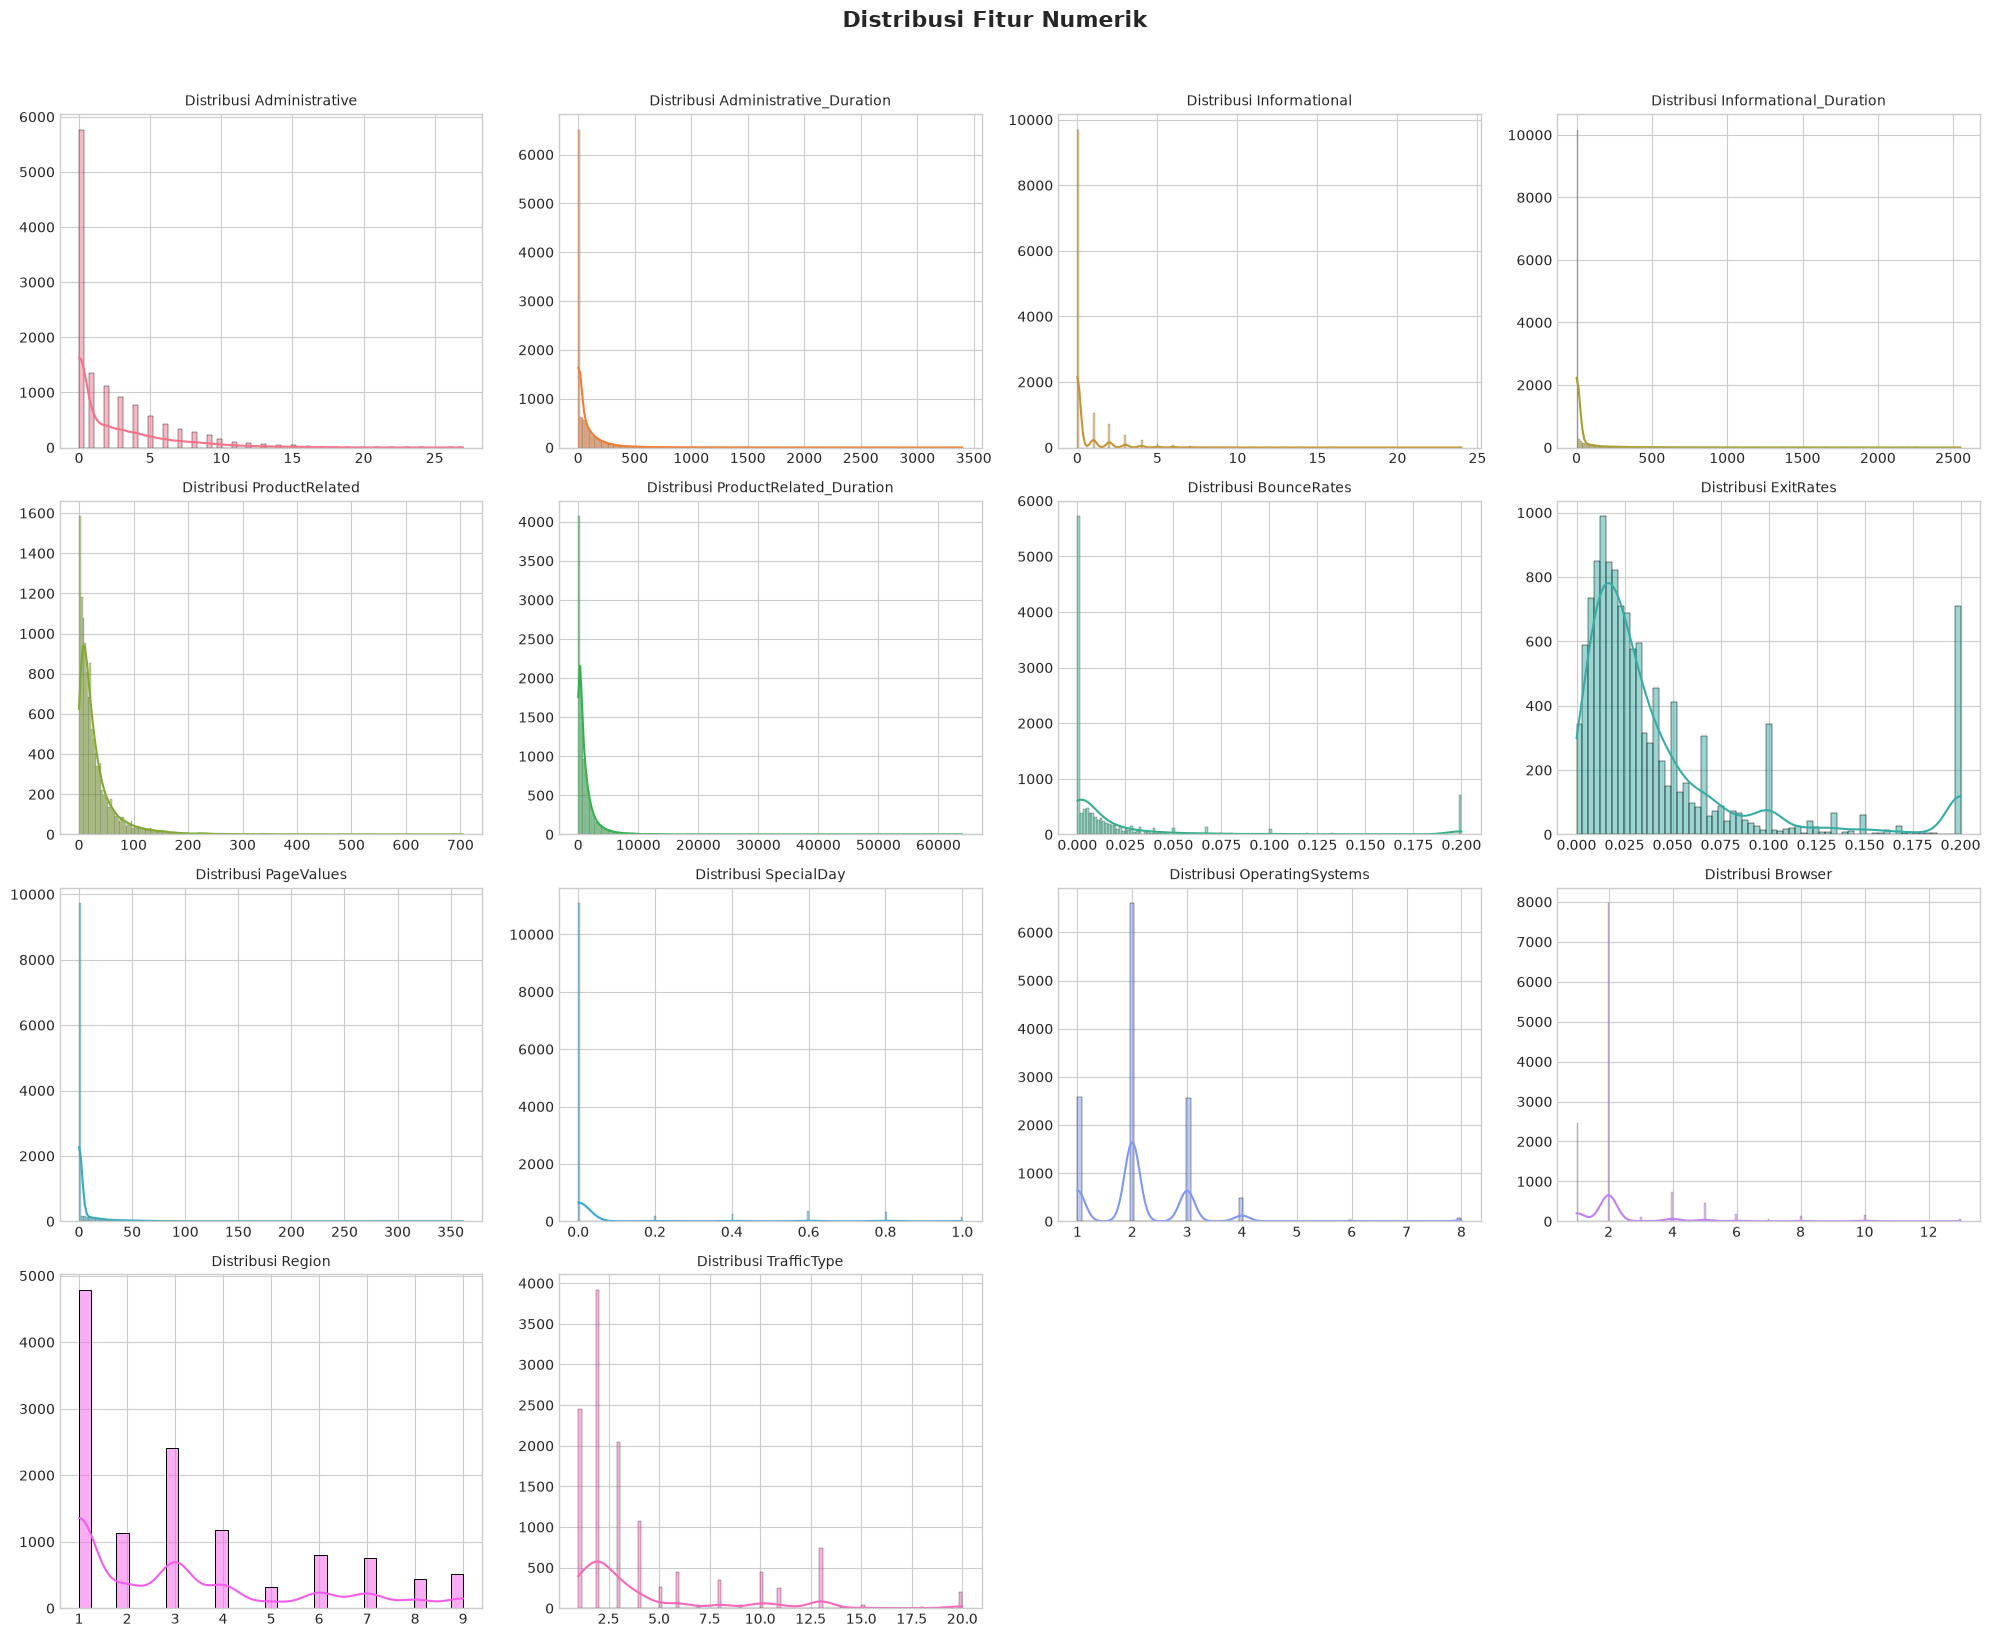

Histogram distribusi fitur numerik disimpan di: ../Outputs/eda_numerical_distributions.png

4b. Box Plot Fitur Numerik Berdasarkan Target


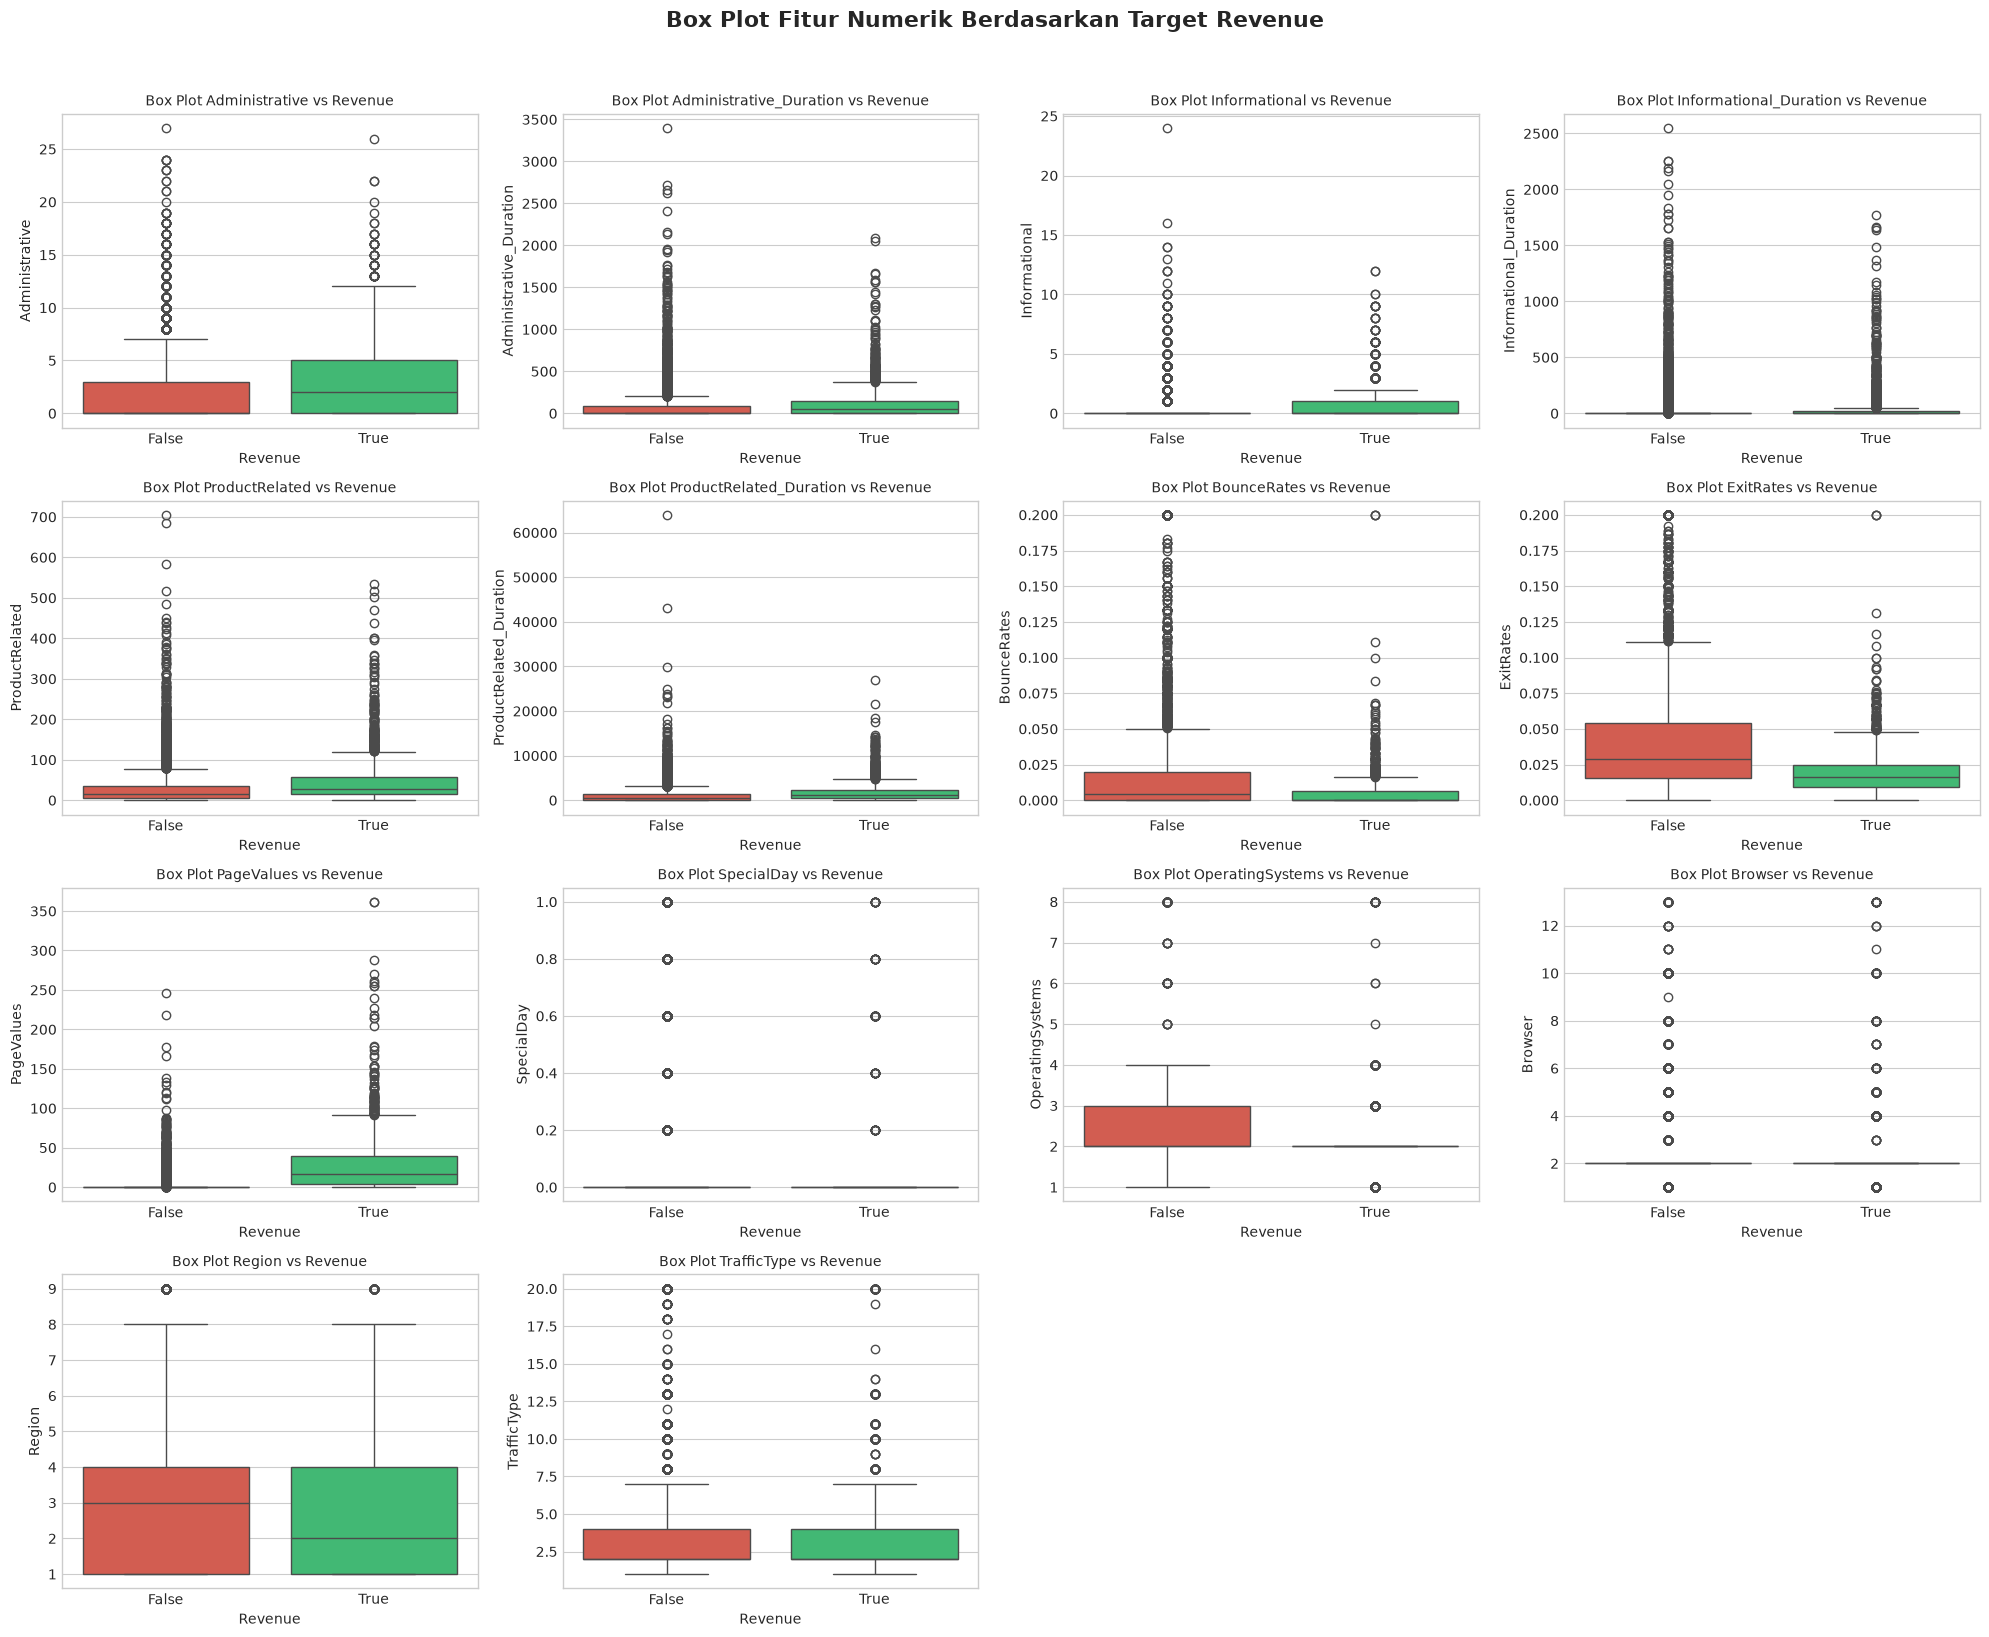

Box plot disimpan di: ../Outputs/eda_boxplots_by_target.png

4c. Distribusi Fitur Kategorikal
Jumlah fitur kategorikal: 4
Fitur kategorikal: ['Month', 'VisitorType', 'Weekend', 'Revenue']


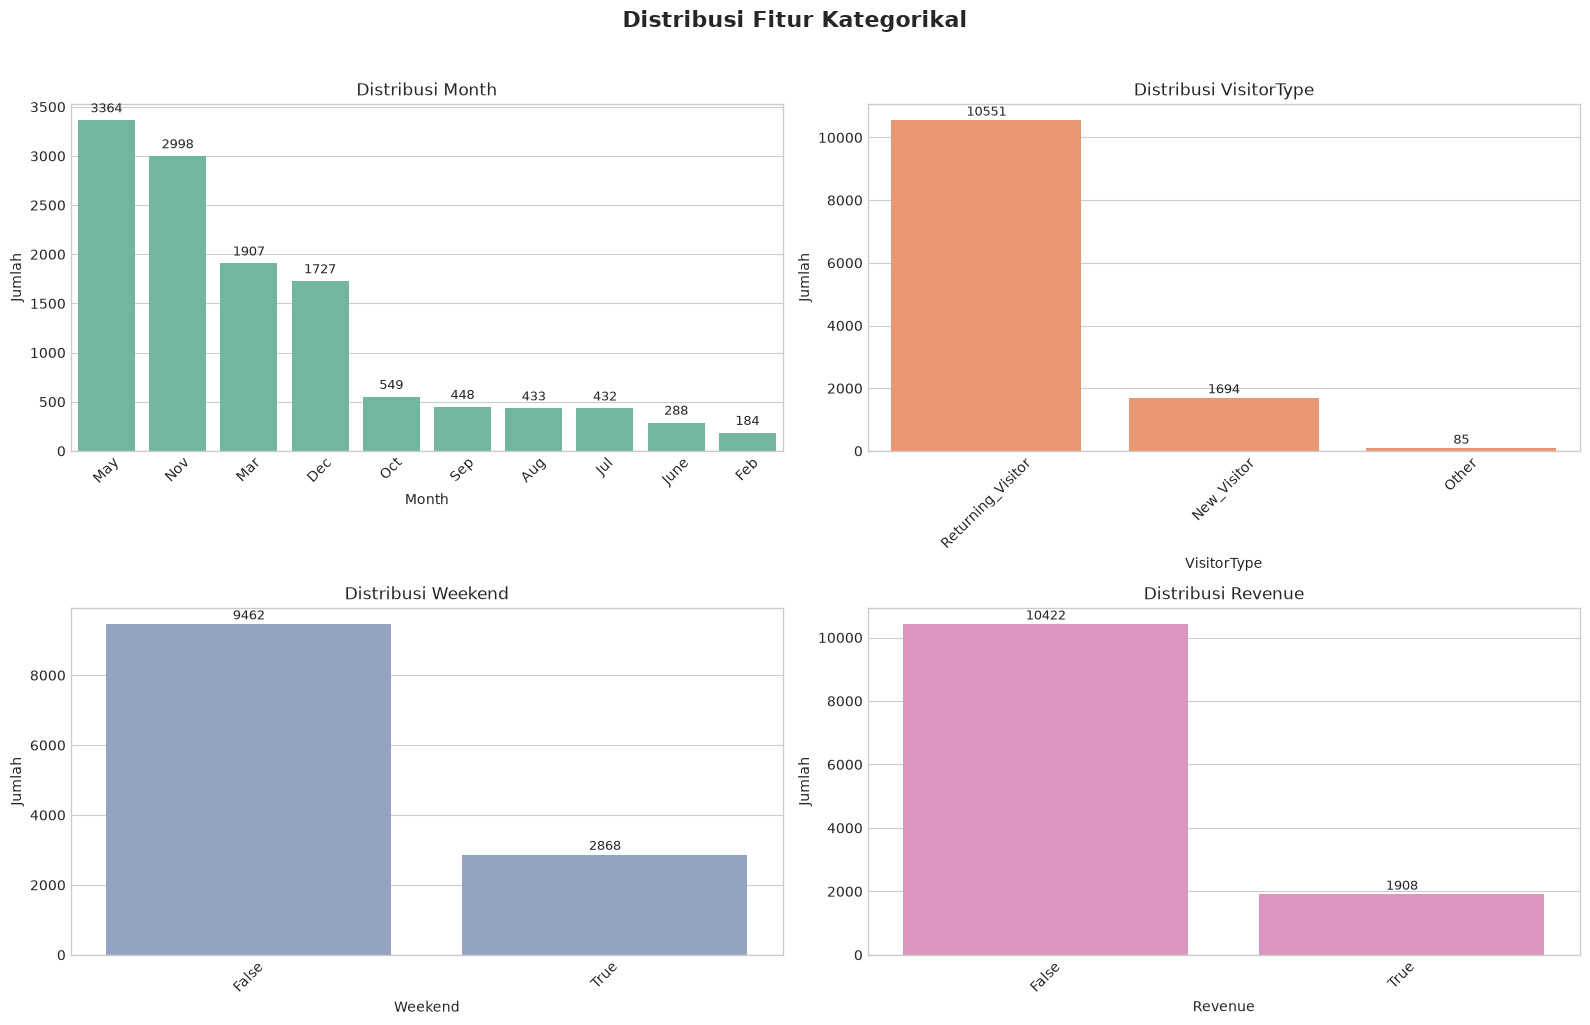

Distribusi kategorikal disimpan di: ../Outputs/eda_categorical_distributions.png

4d. Count Plot Fitur Kategorikal Berdasarkan Target


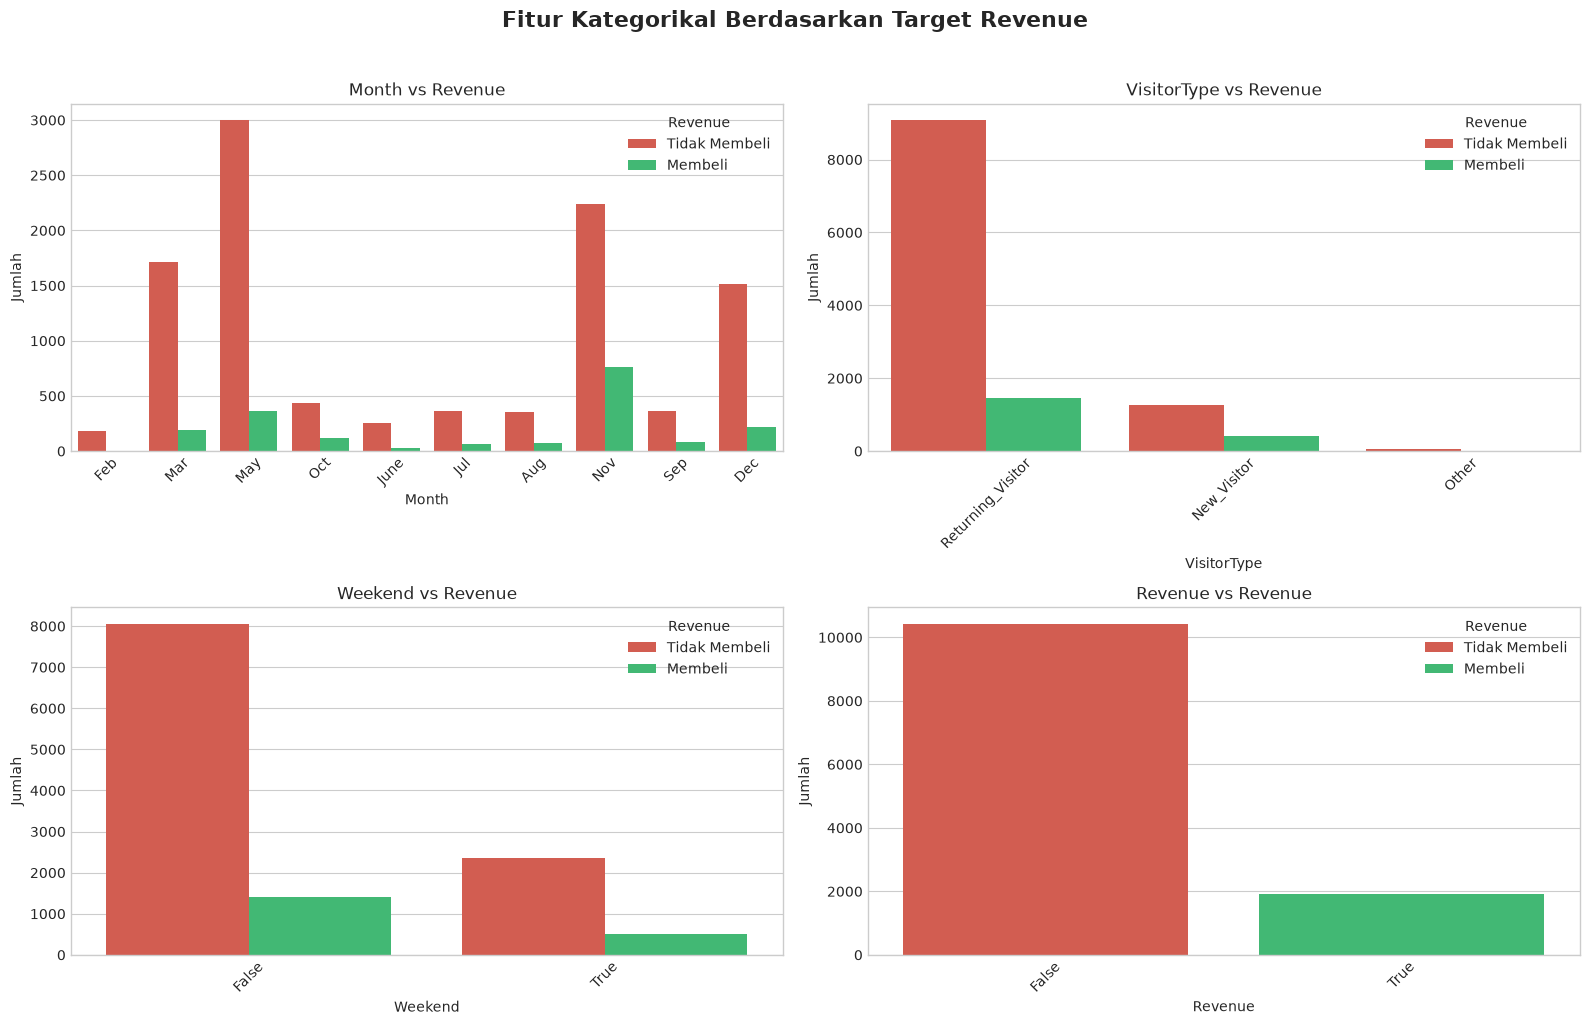

Count plot kategorikal disimpan di: ../Outputs/eda_categorical_by_target.png

4e. Correlation Heatmap


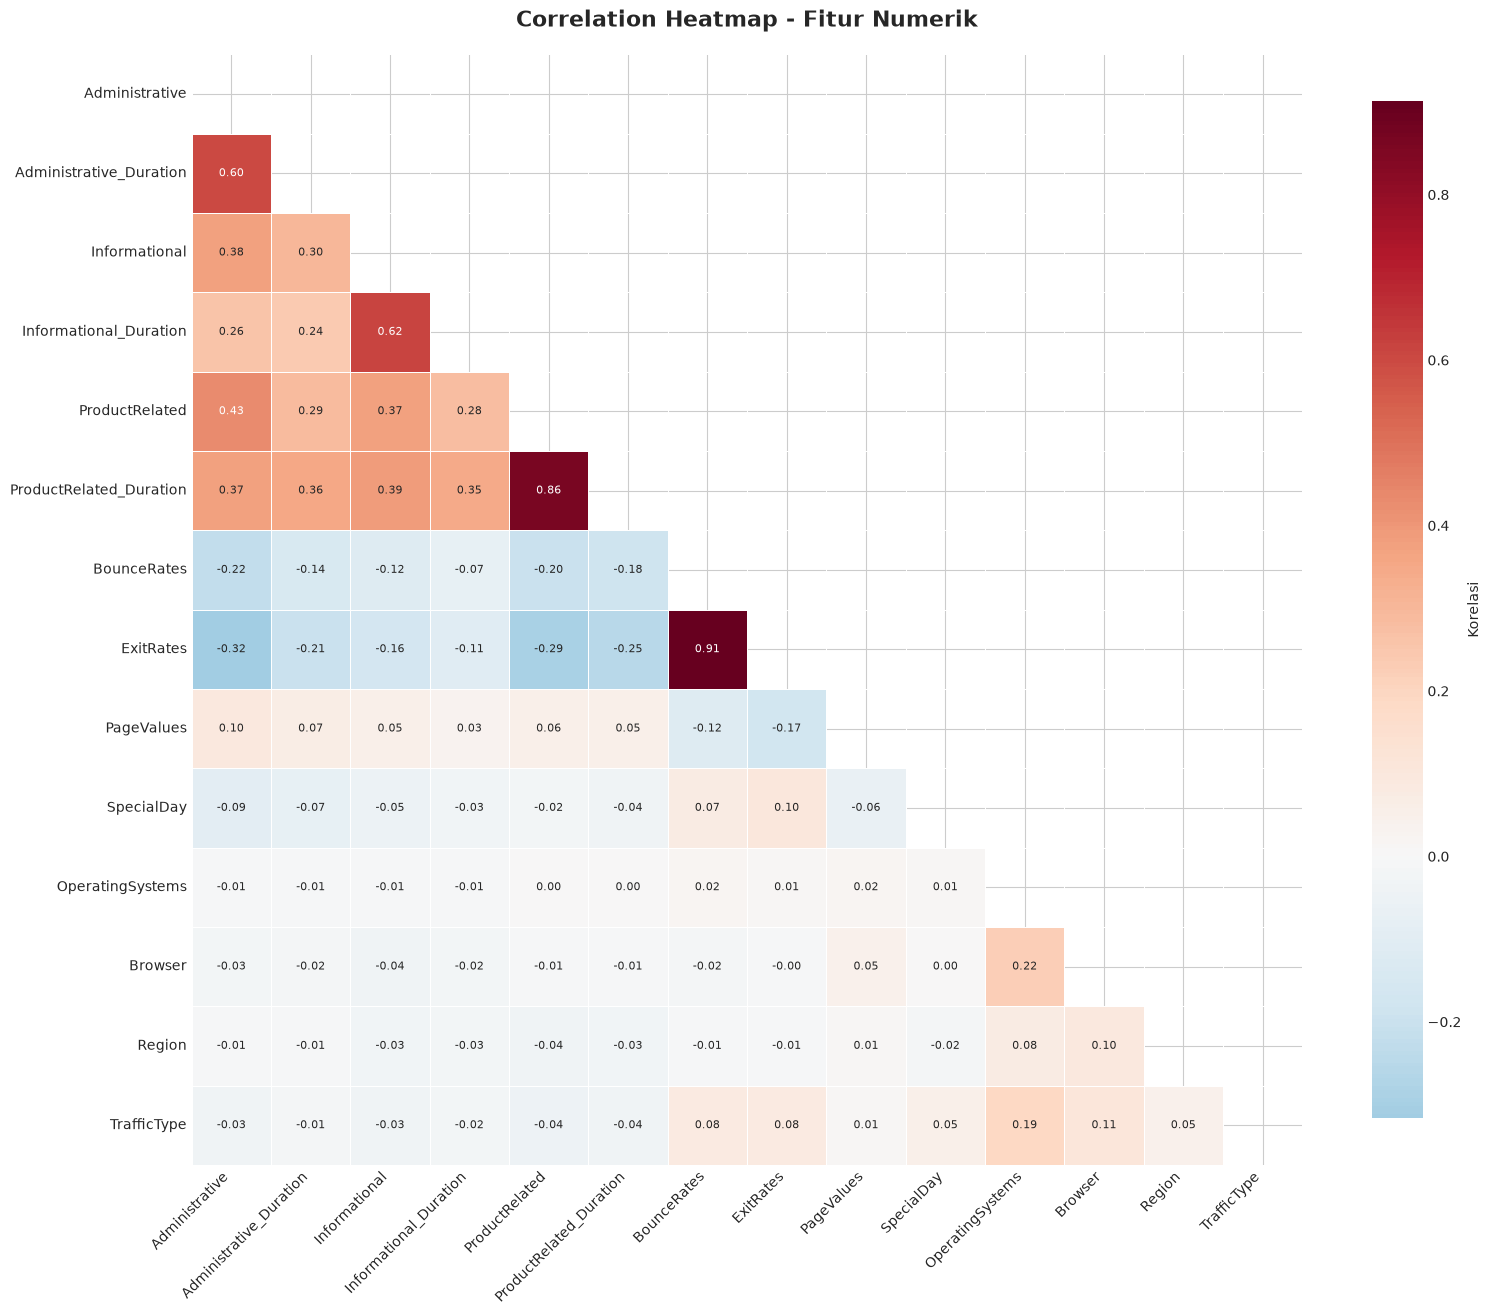

Correlation heatmap disimpan di: ../Outputs/eda_correlation_heatmap.png

Korelasi dengan Target (Revenue):

4f. Korelasi Fitur dengan Target

4g. Pair Plot Fitur Penting

4h. Violin Plot Fitur Numerik Berdasarkan Target


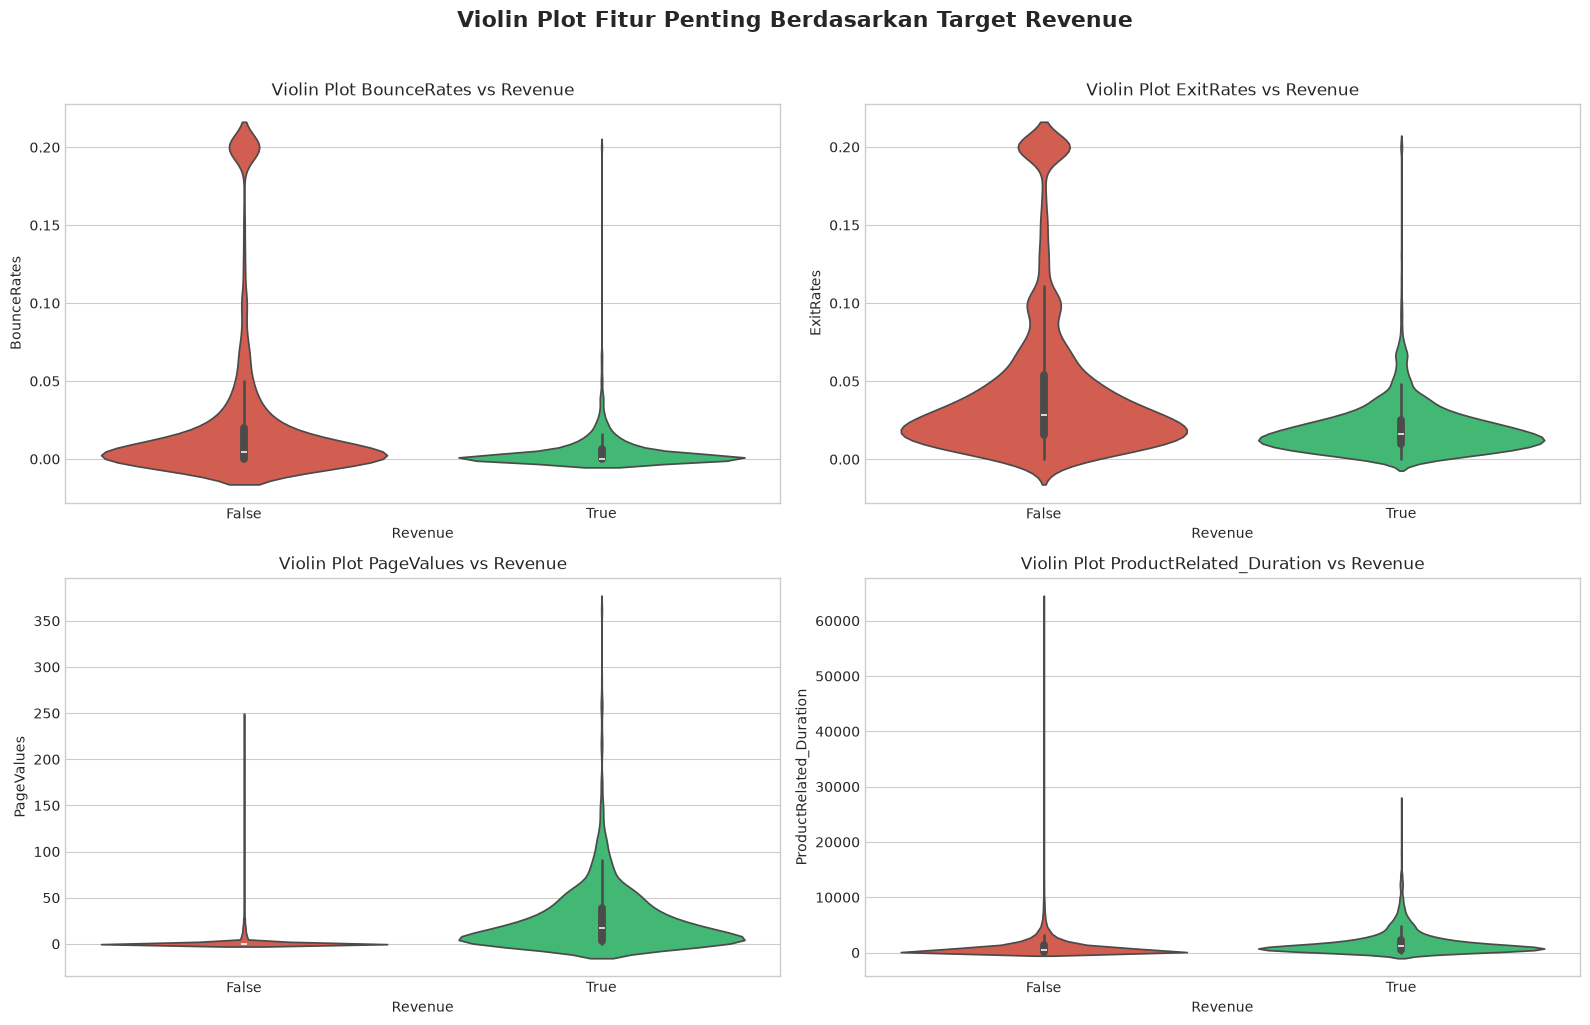

Violin plot disimpan di: ../Outputs/eda_violin_plots.png

4i. KDE Plot Fitur Numerik Berdasarkan Target


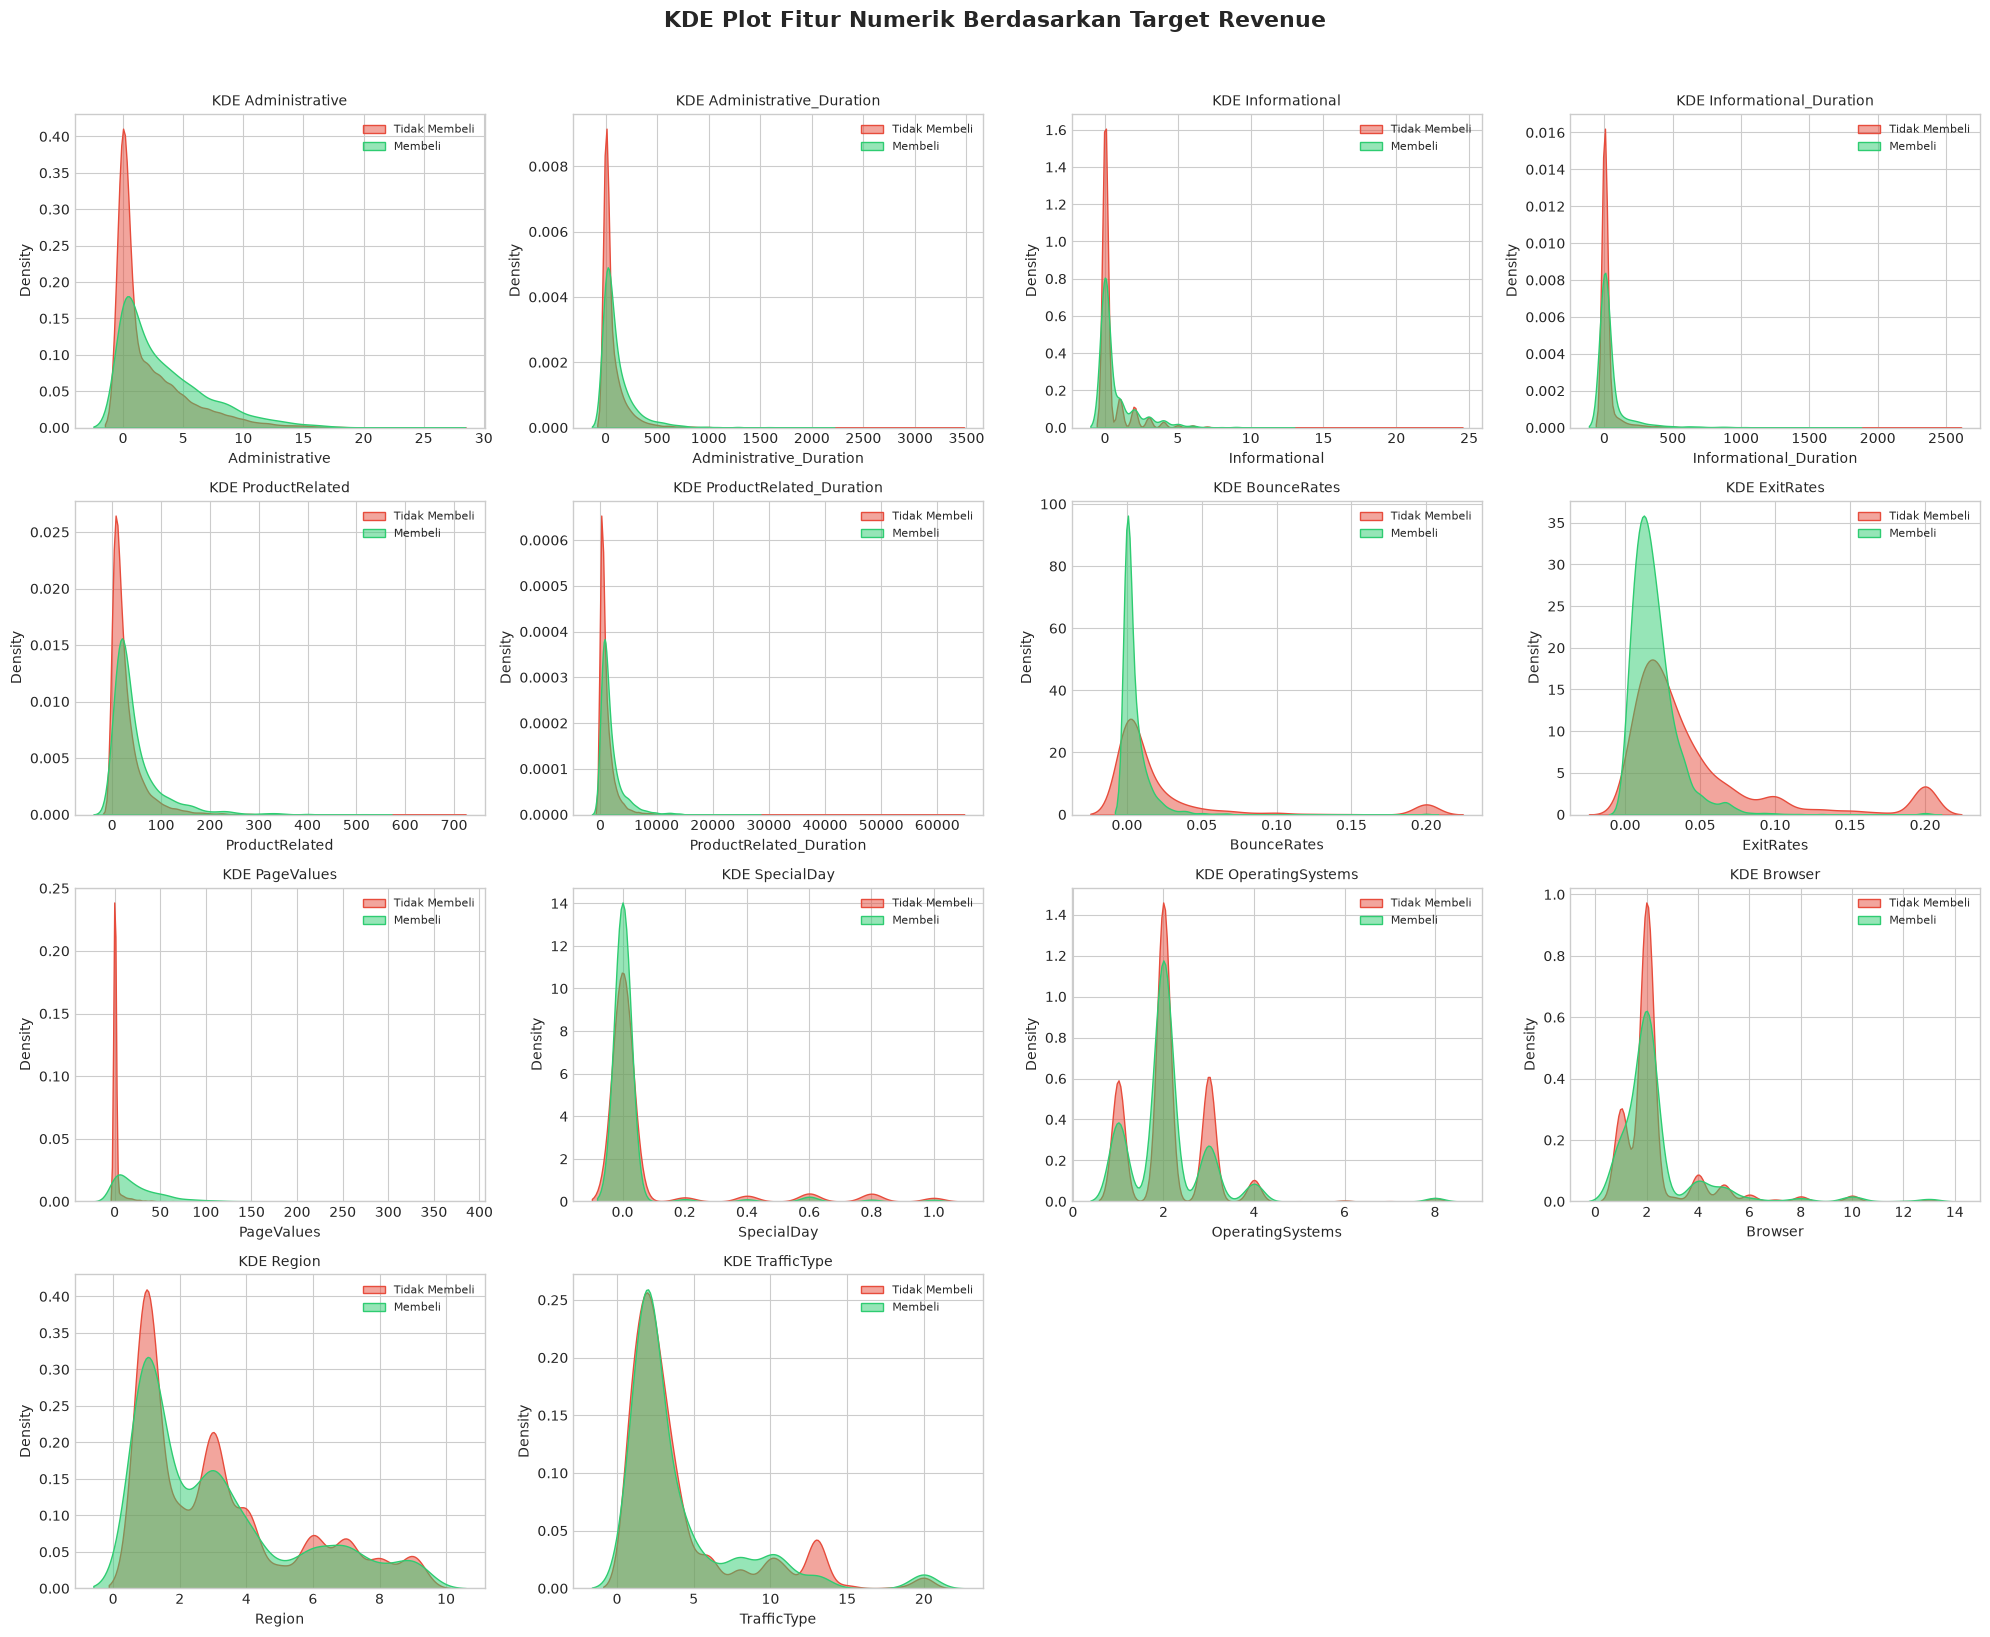

KDE plot disimpan di: ../Outputs/eda_kde_plots.png

4j. Statistical Summary Visualization


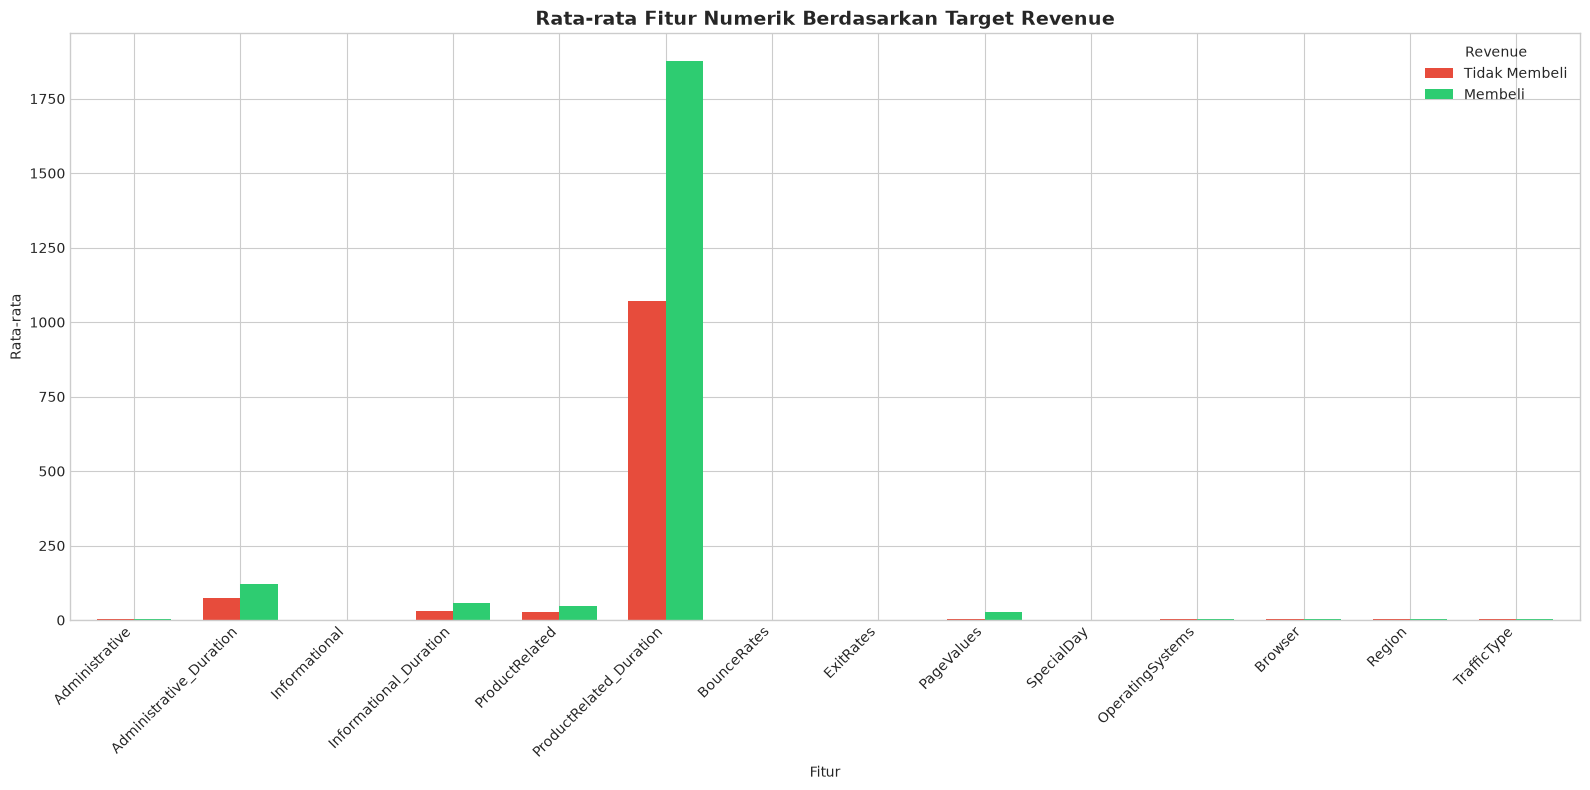

Mean comparison disimpan di: Outputs/eda_mean_comparison.png

EDA Complete - Semua visualisasi disimpan di folder 'Outputs'


In [4]:

# ============================
# 4. Exploratory Data Analysis (EDA)
# ============================

# Set style untuk visualisasi
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

# 4a. Distribusi Fitur Numerik
print("=" * 50)
print("4a. Distribusi Fitur Numerik")
print("=" * 50)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Jumlah fitur numerik: {len(numeric_cols)}")
print(f"Fitur numerik: {numeric_cols}")

# Histogram untuk setiap fitur numerik
n_cols_grid = min(4, len(numeric_cols))
n_rows_grid = (len(numeric_cols) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

palette = sns.color_palette("husl", len(numeric_cols))
for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color=palette[idx])
    axes[idx].set_title(f'Distribusi {col}', fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram distribusi fitur numerik disimpan di: ../Outputs/eda_numerical_distributions.png")

# 4b. Box Plot Fitur Numerik Berdasarkan Target
print("\n" + "=" * 50)
print("4b. Box Plot Fitur Numerik Berdasarkan Target")
print("=" * 50)

n_cols_grid = min(4, len(numeric_cols))
n_rows_grid = (len(numeric_cols) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Revenue', y=col, ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
    axes[idx].set_title(f'Box Plot {col} vs Revenue', fontsize=10)
    axes[idx].set_xlabel('Revenue')
    axes[idx].set_ylabel(col)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Box Plot Fitur Numerik Berdasarkan Target Revenue', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot disimpan di: ../Outputs/eda_boxplots_by_target.png")

# 4c. Distribusi Fitur Kategorikal
print("\n" + "=" * 50)
print("4c. Distribusi Fitur Kategorikal")
print("=" * 50)

categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")
print(f"Fitur kategorikal: {categorical_cols}")

if len(categorical_cols) > 0:
    n_cats = len(categorical_cols)
    n_rows = (n_cats + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    colors = sns.color_palette("Set2", n_cats)
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=axes[idx], palette=[colors[idx]])
        axes[idx].set_title(f'Distribusi {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Jumlah')
        axes[idx].tick_params(axis='x', rotation=45)
        
        # Add count labels on bars
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)
    
    # Hide unused subplots
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_categorical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Distribusi kategorikal disimpan di: ../Outputs/eda_categorical_distributions.png")

# 4d. Count Plot Fitur Kategorikal Berdasarkan Target
print("\n" + "=" * 50)
print("4d. Count Plot Fitur Kategorikal Berdasarkan Target")
print("=" * 50)

if len(categorical_cols) > 0:
    n_cats = len(categorical_cols)
    n_rows = (n_cats + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, hue='Revenue', ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
        axes[idx].set_title(f'{col} vs Revenue', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Jumlah')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='Revenue', labels=['Tidak Membeli', 'Membeli'])
    
    # Hide unused subplots
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Fitur Kategorikal Berdasarkan Target Revenue', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_categorical_by_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Count plot kategorikal disimpan di: ../Outputs/eda_categorical_by_target.png")

# 4e. Correlation Heatmap
print("\n" + "=" * 50)
print("4e. Correlation Heatmap")
print("=" * 50)

# Select only numeric columns for correlation
df_numeric = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Korelasi"},
    annot_kws={"size": 8}
)
plt.title('Correlation Heatmap - Fitur Numerik', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../Outputs/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap disimpan di: ../Outputs/eda_correlation_heatmap.png")

# Print top correlations with target
print("\nKorelasi dengan Target (Revenue):")
if 'Revenue' in correlation_matrix.columns:
    target_corr = correlation_matrix['Revenue'].drop('Revenue').sort_values(ascending=False)
    print(target_corr)

# 4f. Correlation with Target Bar Chart
print("\n" + "=" * 50)
print("4f. Korelasi Fitur dengan Target")
print("=" * 50)

if 'Revenue' in correlation_matrix.columns:
    target_corr = correlation_matrix['Revenue'].drop('Revenue').sort_values()
    
    plt.figure(figsize=(12, 8))
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
    sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.title('Korelasi Fitur dengan Target Revenue', fontsize=14, fontweight='bold')
    plt.xlabel('Korelasi')
    plt.ylabel('Fitur')
    plt.tight_layout()
    plt.savefig('../Outputs/eda_target_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Korelasi dengan target disimpan di: ../Outputs/eda_target_correlation.png")

# 4g. Pair Plot untuk Fitur dengan Korelasi Tertinggi
print("\n" + "=" * 50)
print("4g. Pair Plot Fitur Penting")
print("=" * 50)

# Select top correlated features with target for pairplot
if 'Revenue' in correlation_matrix.columns:
    top_corr_features = correlation_matrix['Revenue'].abs().sort_values(ascending=False).head(6).index.tolist()
    if 'Revenue' in top_corr_features:
        top_corr_features.remove('Revenue')
    
    if len(top_corr_features) >= 4:
        pairplot_data = df[top_corr_features + ['Revenue']].copy()
        pairplot_data['Revenue'] = pairplot_data['Revenue'].map({True: 'Membeli', False: 'Tidak Membeli'})
        
        g = sns.pairplot(pairplot_data, hue='Revenue', palette=['#e74c3c', '#2ecc71'], diag_kind='kde', plot_kws={'alpha': 0.6})
        g.fig.suptitle('Pair Plot Fitur dengan Korelasi Tertinggi', y=1.02, fontsize=14, fontweight='bold')
        plt.savefig('Outputs/eda_pairplot.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Pair plot disimpan di: Outputs/eda_pairplot.png")

# 4h. Violin Plot untuk Fitur Numerik Berdasarkan Target
print("\n" + "=" * 50)
print("4h. Violin Plot Fitur Numerik Berdasarkan Target")
print("=" * 50)

# Select key features for violin plot
key_features = ['BounceRates', 'ExitRates', 'PageValues', 'ProductRelated_Duration']
key_features = [f for f in key_features if f in df.columns]

if len(key_features) > 0:
    n_features = len(key_features)
    n_rows = (n_features + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(key_features):
        sns.violinplot(data=df, x='Revenue', y=col, ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
        axes[idx].set_title(f'Violin Plot {col} vs Revenue', fontsize=12)
        axes[idx].set_xlabel('Revenue')
        axes[idx].set_ylabel(col)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Violin Plot Fitur Penting Berdasarkan Target Revenue', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_violin_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Violin plot disimpan di: ../Outputs/eda_violin_plots.png")

# 4i. Distribusi Fitur Berdasarkan Target (KDE Plot)
print("\n" + "=" * 50)
print("4i. KDE Plot Fitur Numerik Berdasarkan Target")
print("=" * 50)

n_cols_grid = min(4, len(numeric_cols))
n_rows_grid = (len(numeric_cols) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.kdeplot(data=df[df['Revenue'] == False], x=col, ax=axes[idx], color='#e74c3c', label='Tidak Membeli', fill=True, alpha=0.5)
    sns.kdeplot(data=df[df['Revenue'] == True], x=col, ax=axes[idx], color='#2ecc71', label='Membeli', fill=True, alpha=0.5)
    axes[idx].set_title(f'KDE {col}', fontsize=10)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('KDE Plot Fitur Numerik Berdasarkan Target Revenue', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("KDE plot disimpan di: ../Outputs/eda_kde_plots.png")

# 4j. Statistical Summary Visualization
print("\n" + "=" * 50)
print("4j. Statistical Summary Visualization")
print("=" * 50)

# Mean comparison by target
if 'Revenue' in df.columns:
    numeric_with_target = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    mean_by_target = df.groupby('Revenue')[numeric_with_target].mean()
    
    fig, ax = plt.subplots(figsize=(16, 8))
    mean_by_target.T.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.7)
    plt.title('Rata-rata Fitur Numerik Berdasarkan Target Revenue', fontsize=14, fontweight='bold')
    plt.xlabel('Fitur')
    plt.ylabel('Rata-rata')
    plt.xticks(rotation=45, ha='right')
    plt.legend(['Tidak Membeli', 'Membeli'], title='Revenue')
    plt.tight_layout()
    plt.savefig('../Outputs/eda_mean_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Mean comparison disimpan di: Outputs/eda_mean_comparison.png")

print("\n" + "=" * 50)
print("EDA Complete - Semua visualisasi disimpan di folder 'Outputs'")
print("=" * 50)

## 5. Cek Missing Value

Missing value adalah data kosong yang dapat mempengaruhi proses pelatihan model. Oleh karena itu, perlu dilakukan pengecekan apakah terdapat nilai kosong pada dataset.

In [5]:

# ============================
# 5. Cek Missing Value
# ============================

missing_values = df.isnull().sum()

print("Jumlah missing value pada setiap kolom:")
print(missing_values)

print("\nTotal missing value:", missing_values.sum())

Jumlah missing value pada setiap kolom:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total missing value: 0


## 6. Cek dan Hapus Data Duplikat

Data duplikat adalah data yang memiliki nilai sama persis dengan data lain. Data duplikat perlu dihapus agar model tidak mempelajari data yang berulang secara berlebihan.

In [6]:

# ============================
# 6. Cek dan Hapus Data Duplikat
# ============================

jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

df_clean = df.drop_duplicates()

print("Ukuran dataset sebelum menghapus duplikat:", df.shape)
print("Ukuran dataset setelah menghapus duplikat:", df_clean.shape)

Jumlah data duplikat: 125
Ukuran dataset sebelum menghapus duplikat: (12330, 18)
Ukuran dataset setelah menghapus duplikat: (12205, 18)


## 6. Cek Distribusi Target

Target pada proyek ini adalah kolom `Revenue`.

Keterangan:
- `False` = Pengunjung tidak melakukan pembelian
- `True` = Pengunjung melakukan pembelian

Distribusi target perlu dicek untuk mengetahui apakah data seimbang atau tidak.

In [7]:

# ============================
# 6. Cek Distribusi Target
# ============================

target_count = df_clean['Revenue'].value_counts()
target_percent = df_clean['Revenue'].value_counts(normalize=True) * 100

print("Jumlah data pada setiap kelas:")
print(target_count)

print("\nPersentase data pada setiap kelas:")
print(target_percent)

Jumlah data pada setiap kelas:
Revenue
False    10297
True      1908
Name: count, dtype: int64

Persentase data pada setiap kelas:
Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


## 7. Visualisasi Distribusi Target

Visualisasi dilakukan untuk melihat perbandingan jumlah pengunjung yang membeli dan tidak membeli secara lebih jelas.

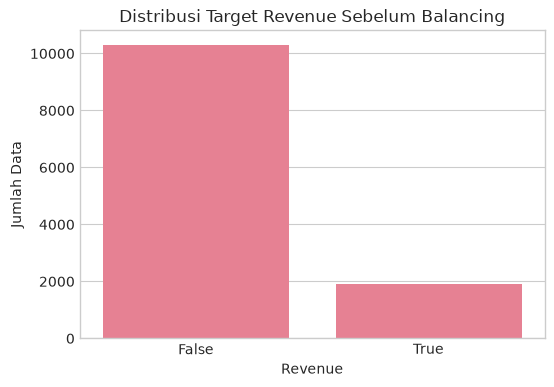

In [8]:

# ============================
# 7. Visualisasi Distribusi Target
# ============================

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Revenue')
plt.title('Distribusi Target Revenue Sebelum Balancing')
plt.xlabel('Revenue')
plt.ylabel('Jumlah Data')
plt.show()

Berdasarkan visualisasi, terlihat bahwa jumlah data pengunjung yang tidak melakukan pembelian lebih banyak dibandingkan pengunjung yang melakukan pembelian. Hal ini menunjukkan bahwa dataset tidak seimbang.

## 8. Balancing Data dengan Undersampling

Karena dataset memiliki distribusi kelas yang tidak seimbang, maka dilakukan proses balancing menggunakan metode undersampling.

Undersampling dilakukan dengan cara mengurangi jumlah data pada kelas mayoritas agar jumlahnya sama dengan kelas minoritas.

Pada dataset ini:
- Kelas mayoritas = Tidak Membeli (`False`)
- Kelas minoritas = Membeli (`True`)

In [9]:

# ============================
# 8. Balancing Data dengan Undersampling
# ============================

# Memisahkan data berdasarkan kelas target
df_tidak_membeli = df_clean[df_clean['Revenue'] == False]
df_membeli = df_clean[df_clean['Revenue'] == True]

# Menentukan jumlah data minoritas
jumlah_minoritas = len(df_membeli)

print("Jumlah data Tidak Membeli sebelum balancing:", len(df_tidak_membeli))
print("Jumlah data Membeli sebelum balancing:", len(df_membeli))

# Mengambil sebagian data kelas mayoritas secara acak
df_tidak_membeli_sample = df_tidak_membeli.sample(
    n=jumlah_minoritas,
    random_state=42
)

# Menggabungkan kembali data mayoritas yang sudah dipotong dengan data minoritas
df_balanced = pd.concat([df_tidak_membeli_sample, df_membeli])

# Mengacak urutan data agar tidak berurutan berdasarkan kelas
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi target setelah balancing:")
print(df_balanced['Revenue'].value_counts())

print("\nUkuran dataset setelah balancing:", df_balanced.shape)

Jumlah data Tidak Membeli sebelum balancing: 10297
Jumlah data Membeli sebelum balancing: 1908

Distribusi target setelah balancing:
Revenue
False    1908
True     1908
Name: count, dtype: int64

Ukuran dataset setelah balancing: (3816, 18)


## 9. Visualisasi Target Setelah Balancing

Setelah proses undersampling, distribusi target divisualisasikan kembali untuk memastikan jumlah kelas membeli dan tidak membeli sudah seimbang.

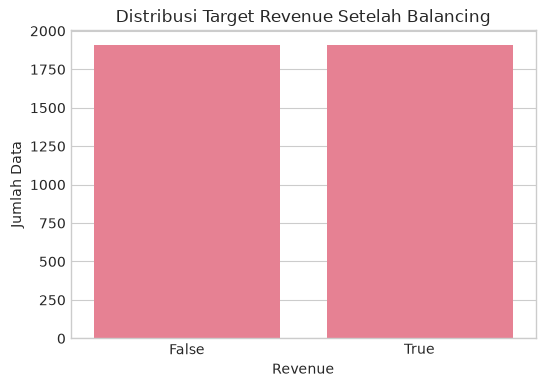

In [10]:

# ============================
# 9. Visualisasi Target Setelah Balancing
# ============================

plt.figure(figsize=(6, 4))
sns.countplot(data=df_balanced, x='Revenue')
plt.title('Distribusi Target Revenue Setelah Balancing')
plt.xlabel('Revenue')
plt.ylabel('Jumlah Data')
plt.show()

## 9b. EDA Setelah Balancing

Tahap EDA setelah balancing dilakukan untuk memahami karakteristik data yang sudah seimbang. Visualisasi dibuat untuk setiap fitur, termasuk distribusi, korelasi, dan hubungannya dengan target.

9b.1 Distribusi Fitur Numerik Setelah Balancing


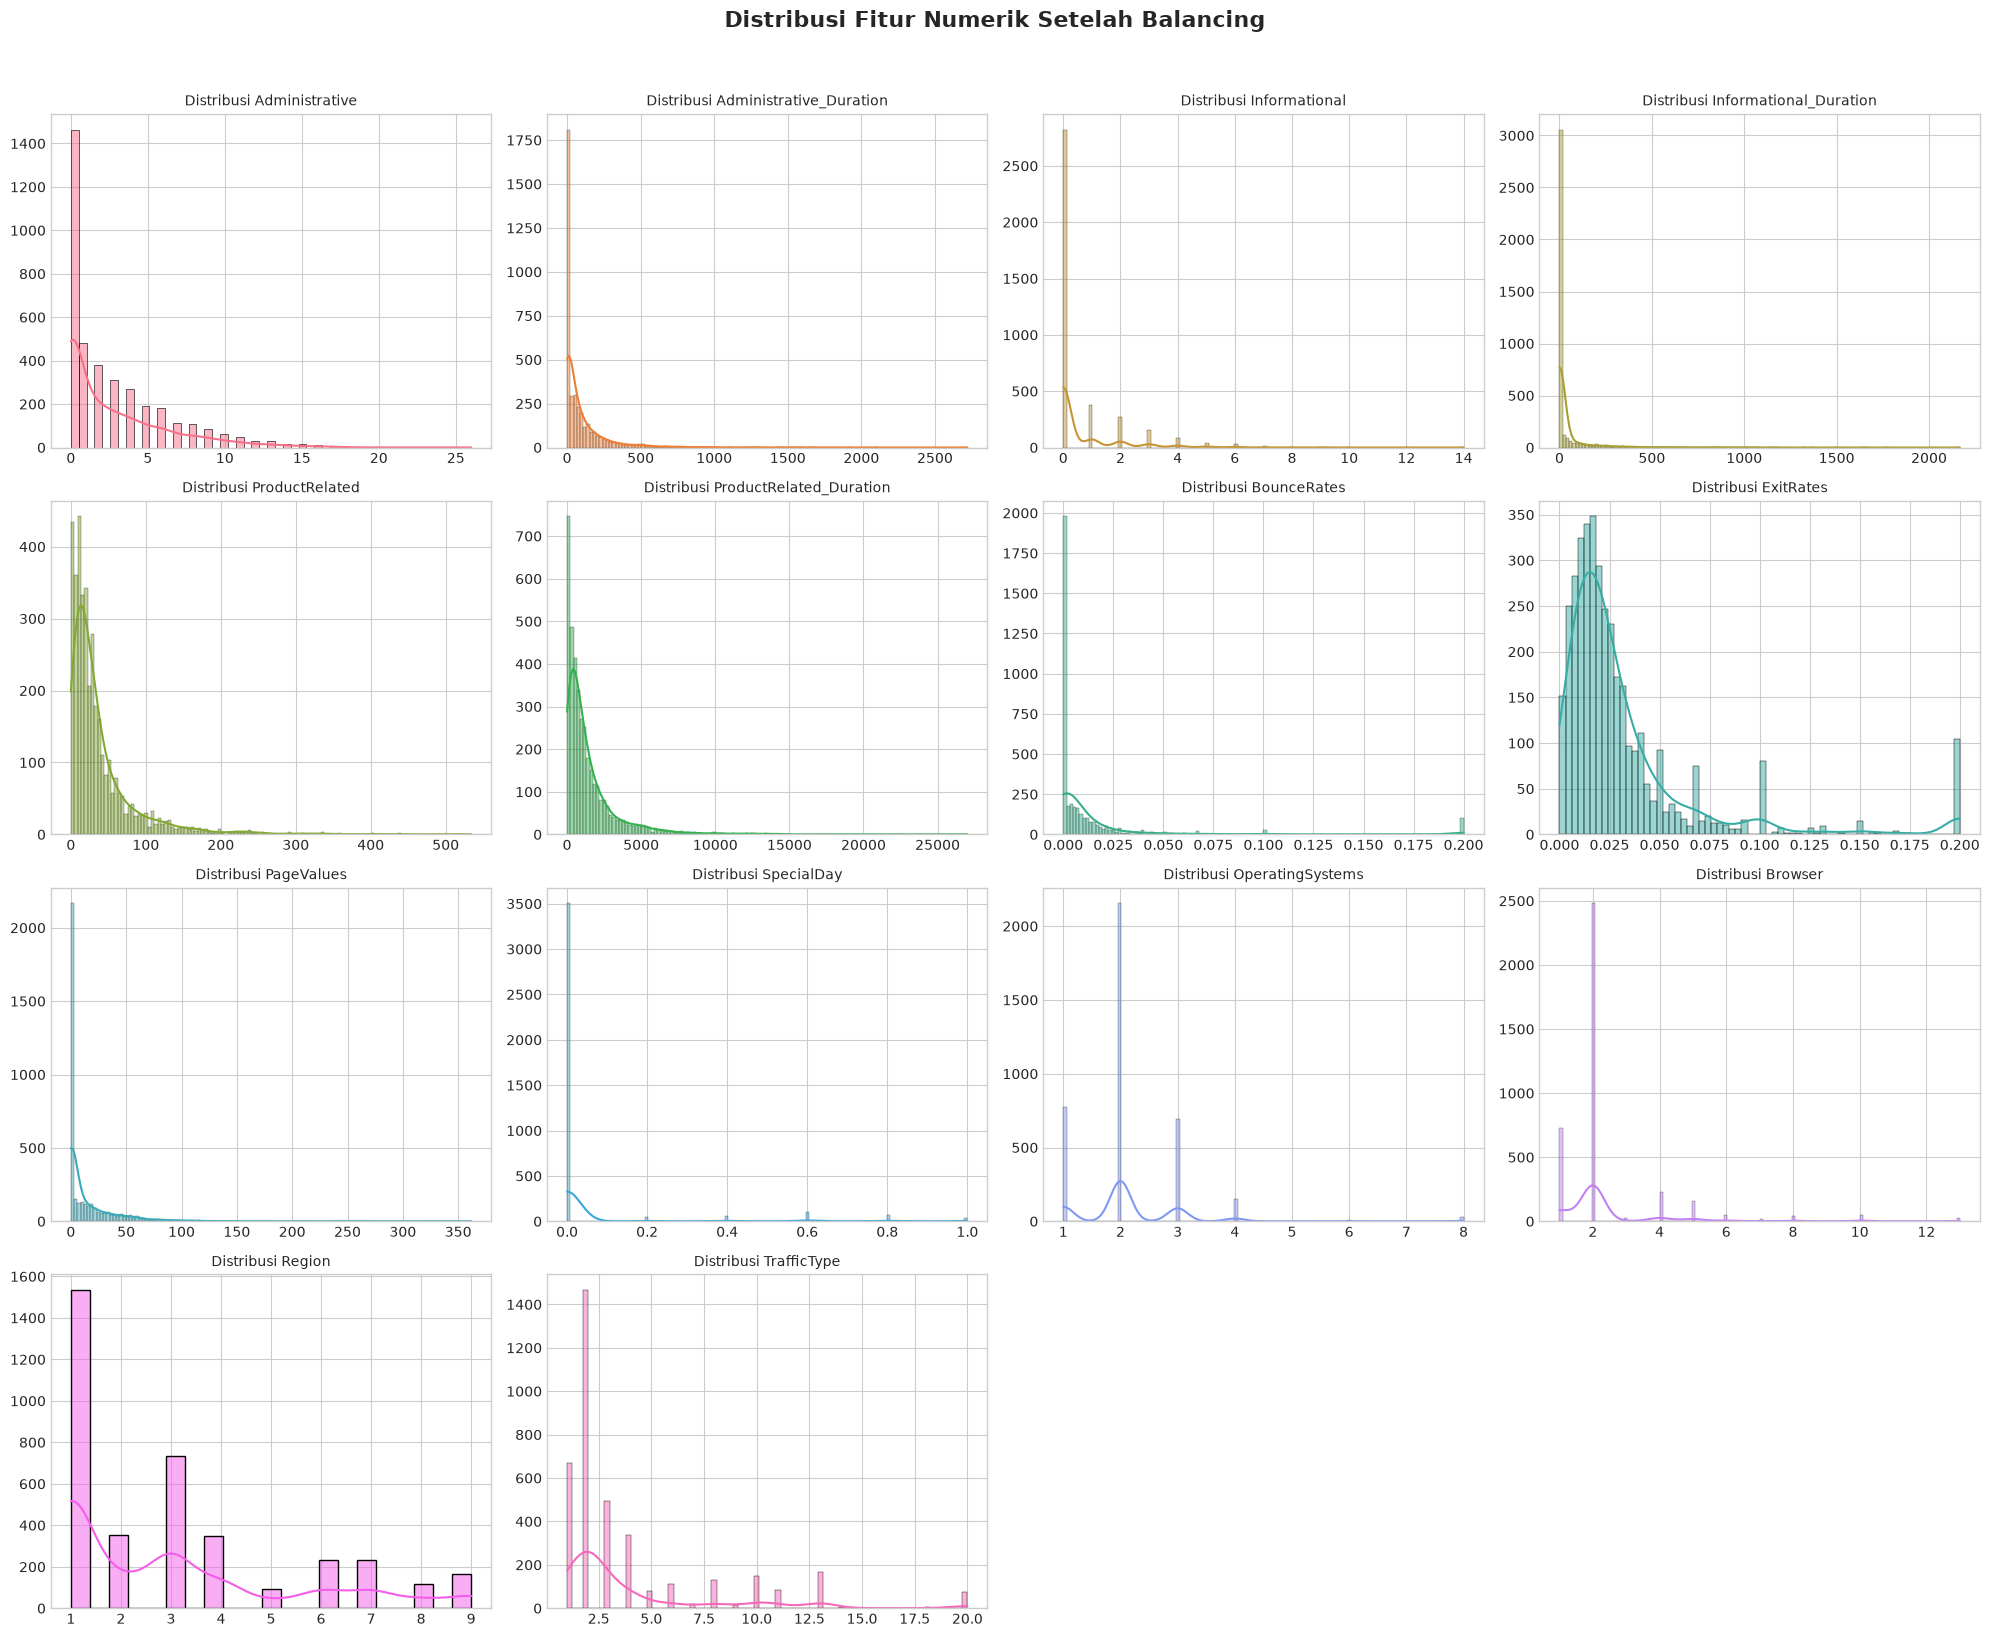

Histogram distribusi fitur numerik setelah balancing disimpan di: ../Outputs/eda_balanced_numerical_distributions.png

9b.2 Box Plot Fitur Numerik Berdasarkan Target Setelah Balancing


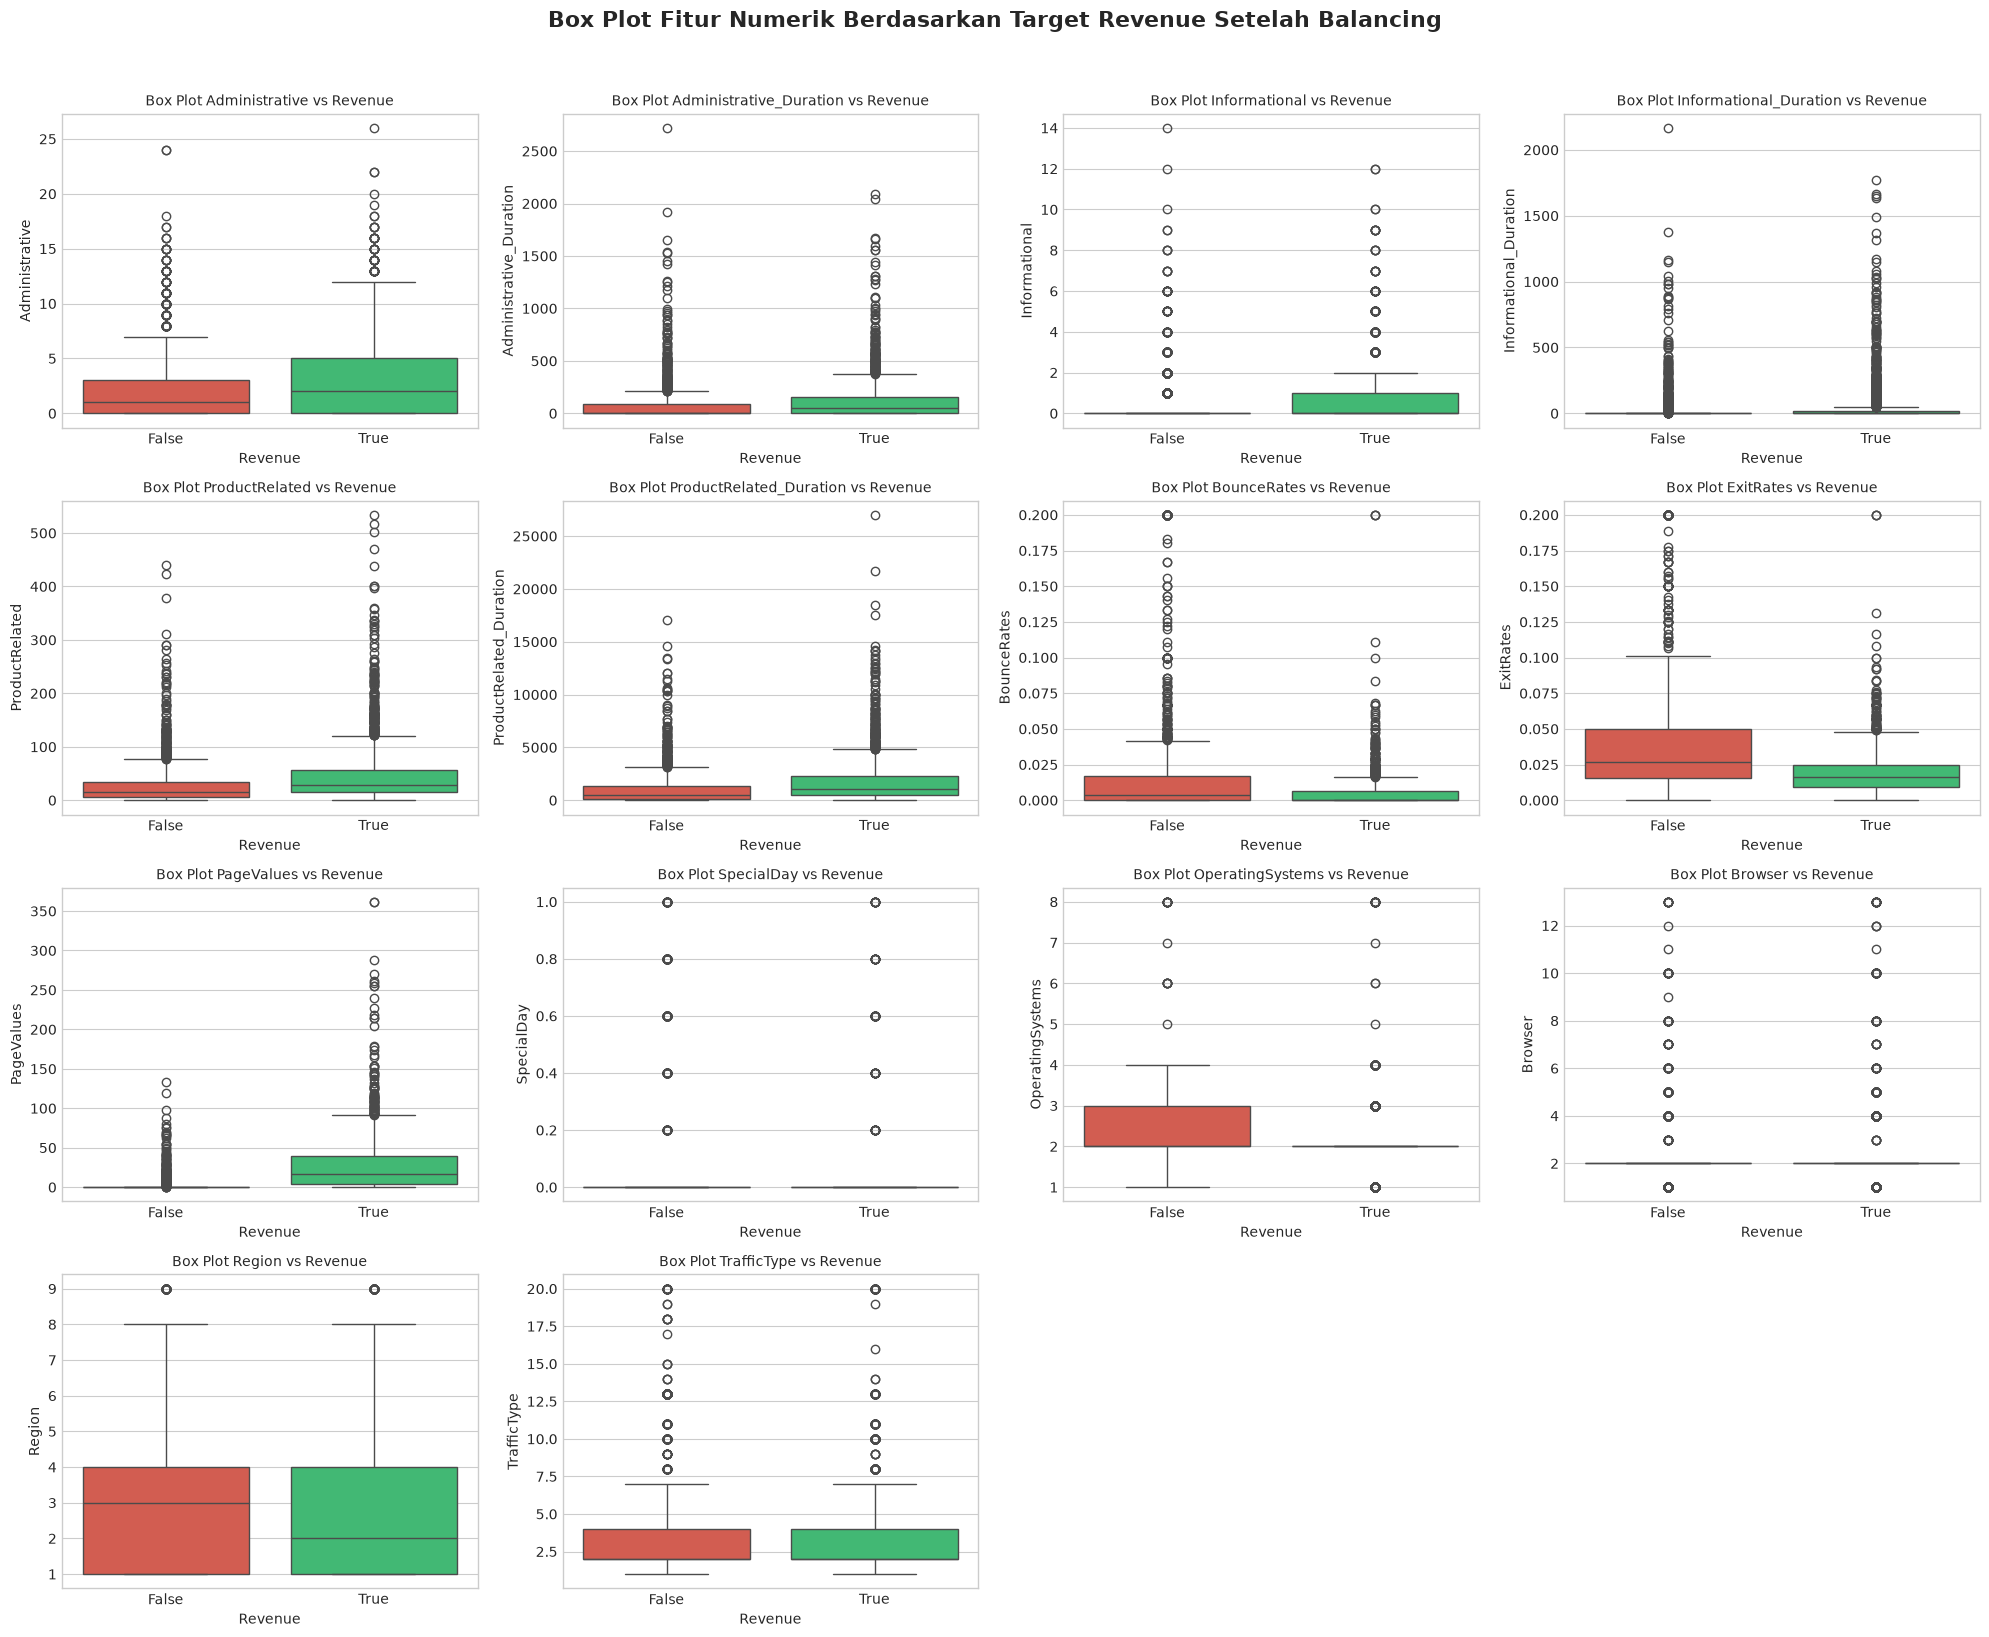

Box plot setelah balancing disimpan di: ../Outputs/eda_balanced_boxplots_by_target.png

9b.3 Distribusi Fitur Kategorikal Setelah Balancing


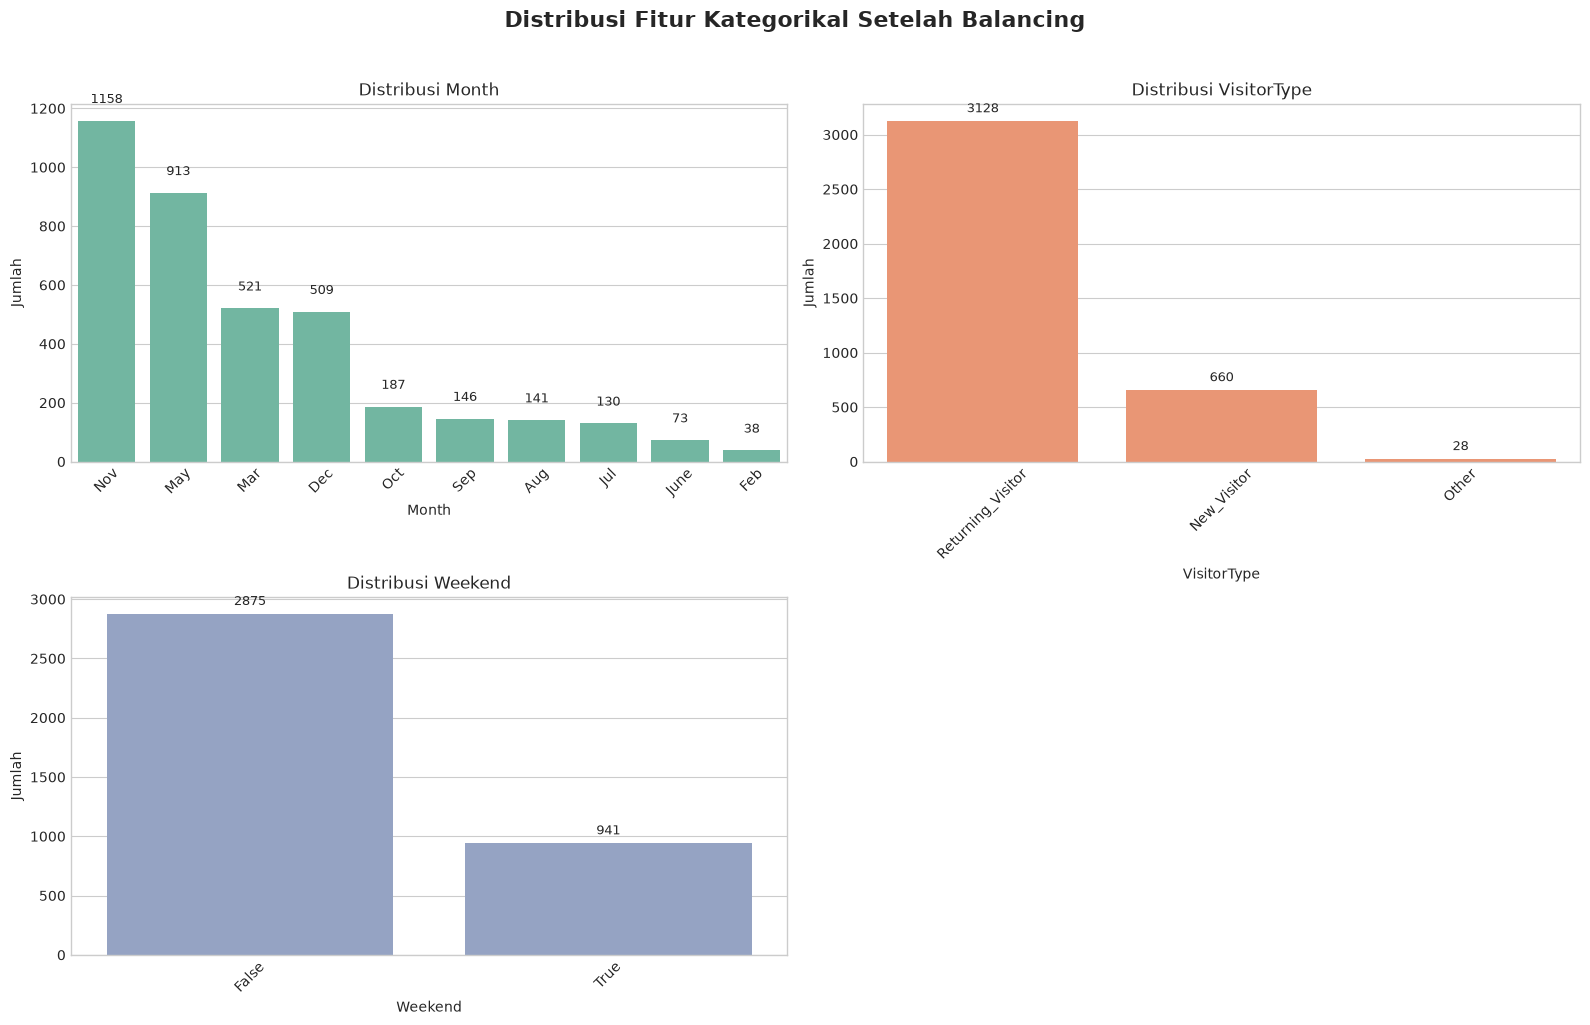

Distribusi kategorikal setelah balancing disimpan di: ../Outputs/eda_balanced_categorical_distributions.png

9b.4 Count Plot Fitur Kategorikal Berdasarkan Target Setelah Balancing


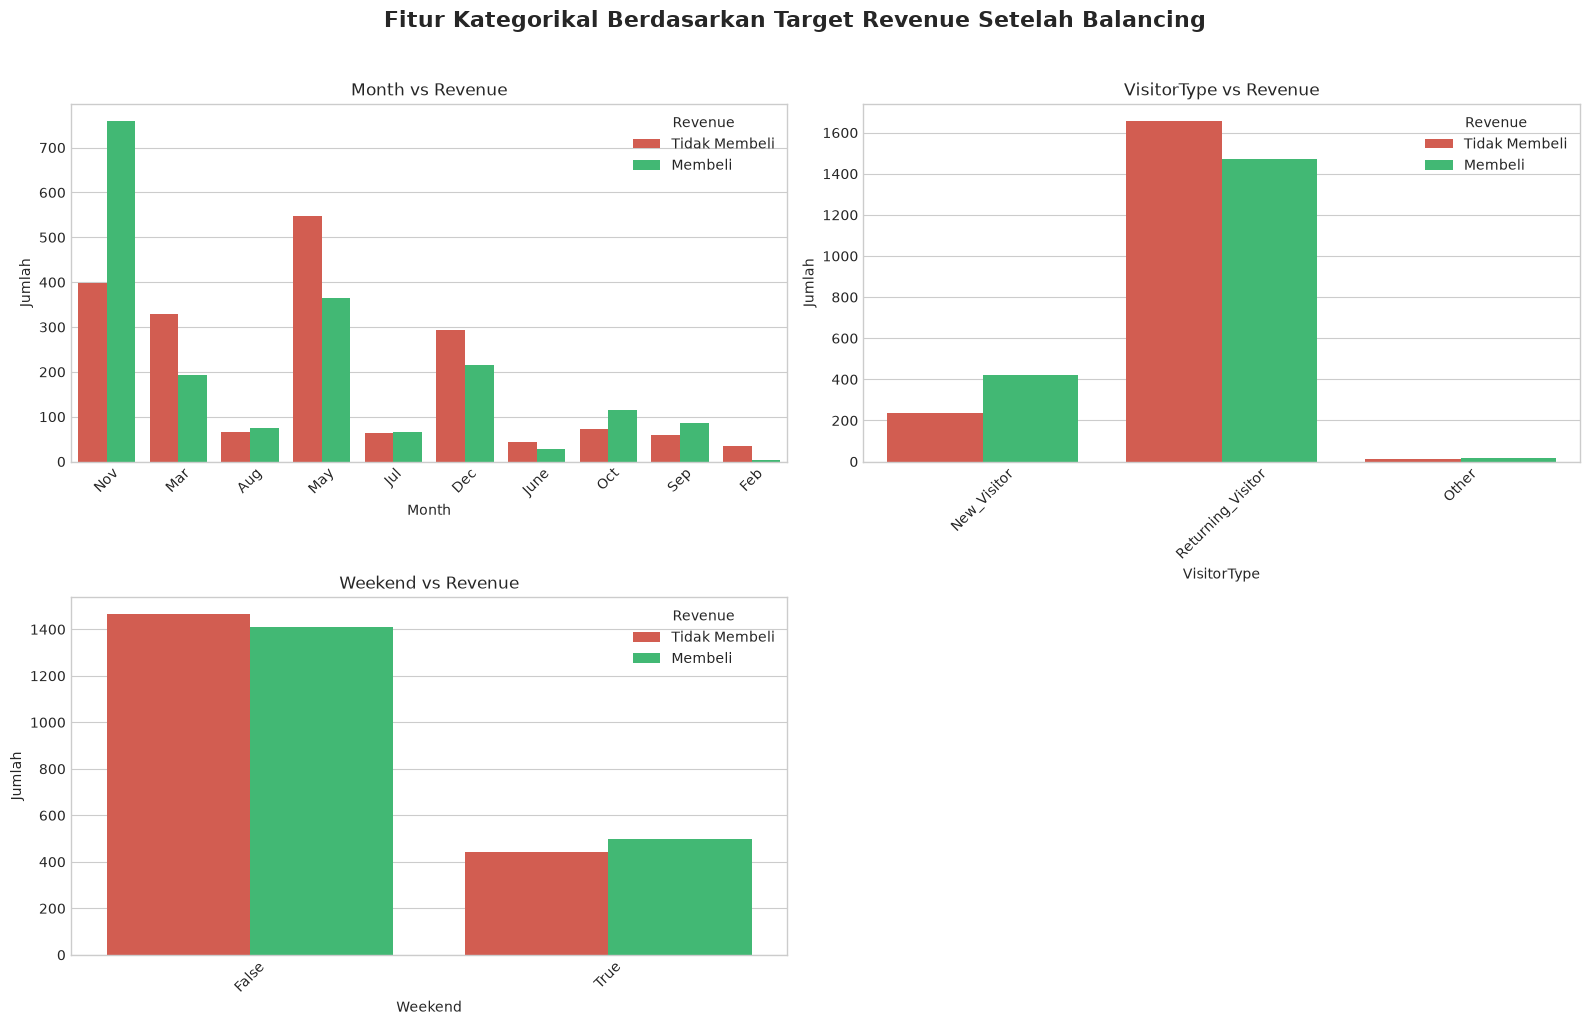

Count plot kategorikal setelah balancing disimpan di: ../Outputs/eda_balanced_categorical_by_target.png

9b.5 Correlation Heatmap Setelah Balancing - Top 5 Fitur

9b.6 Korelasi Fitur dengan Target Setelah Balancing

9b.7 KDE Plot Fitur Numerik Berdasarkan Target Setelah Balancing


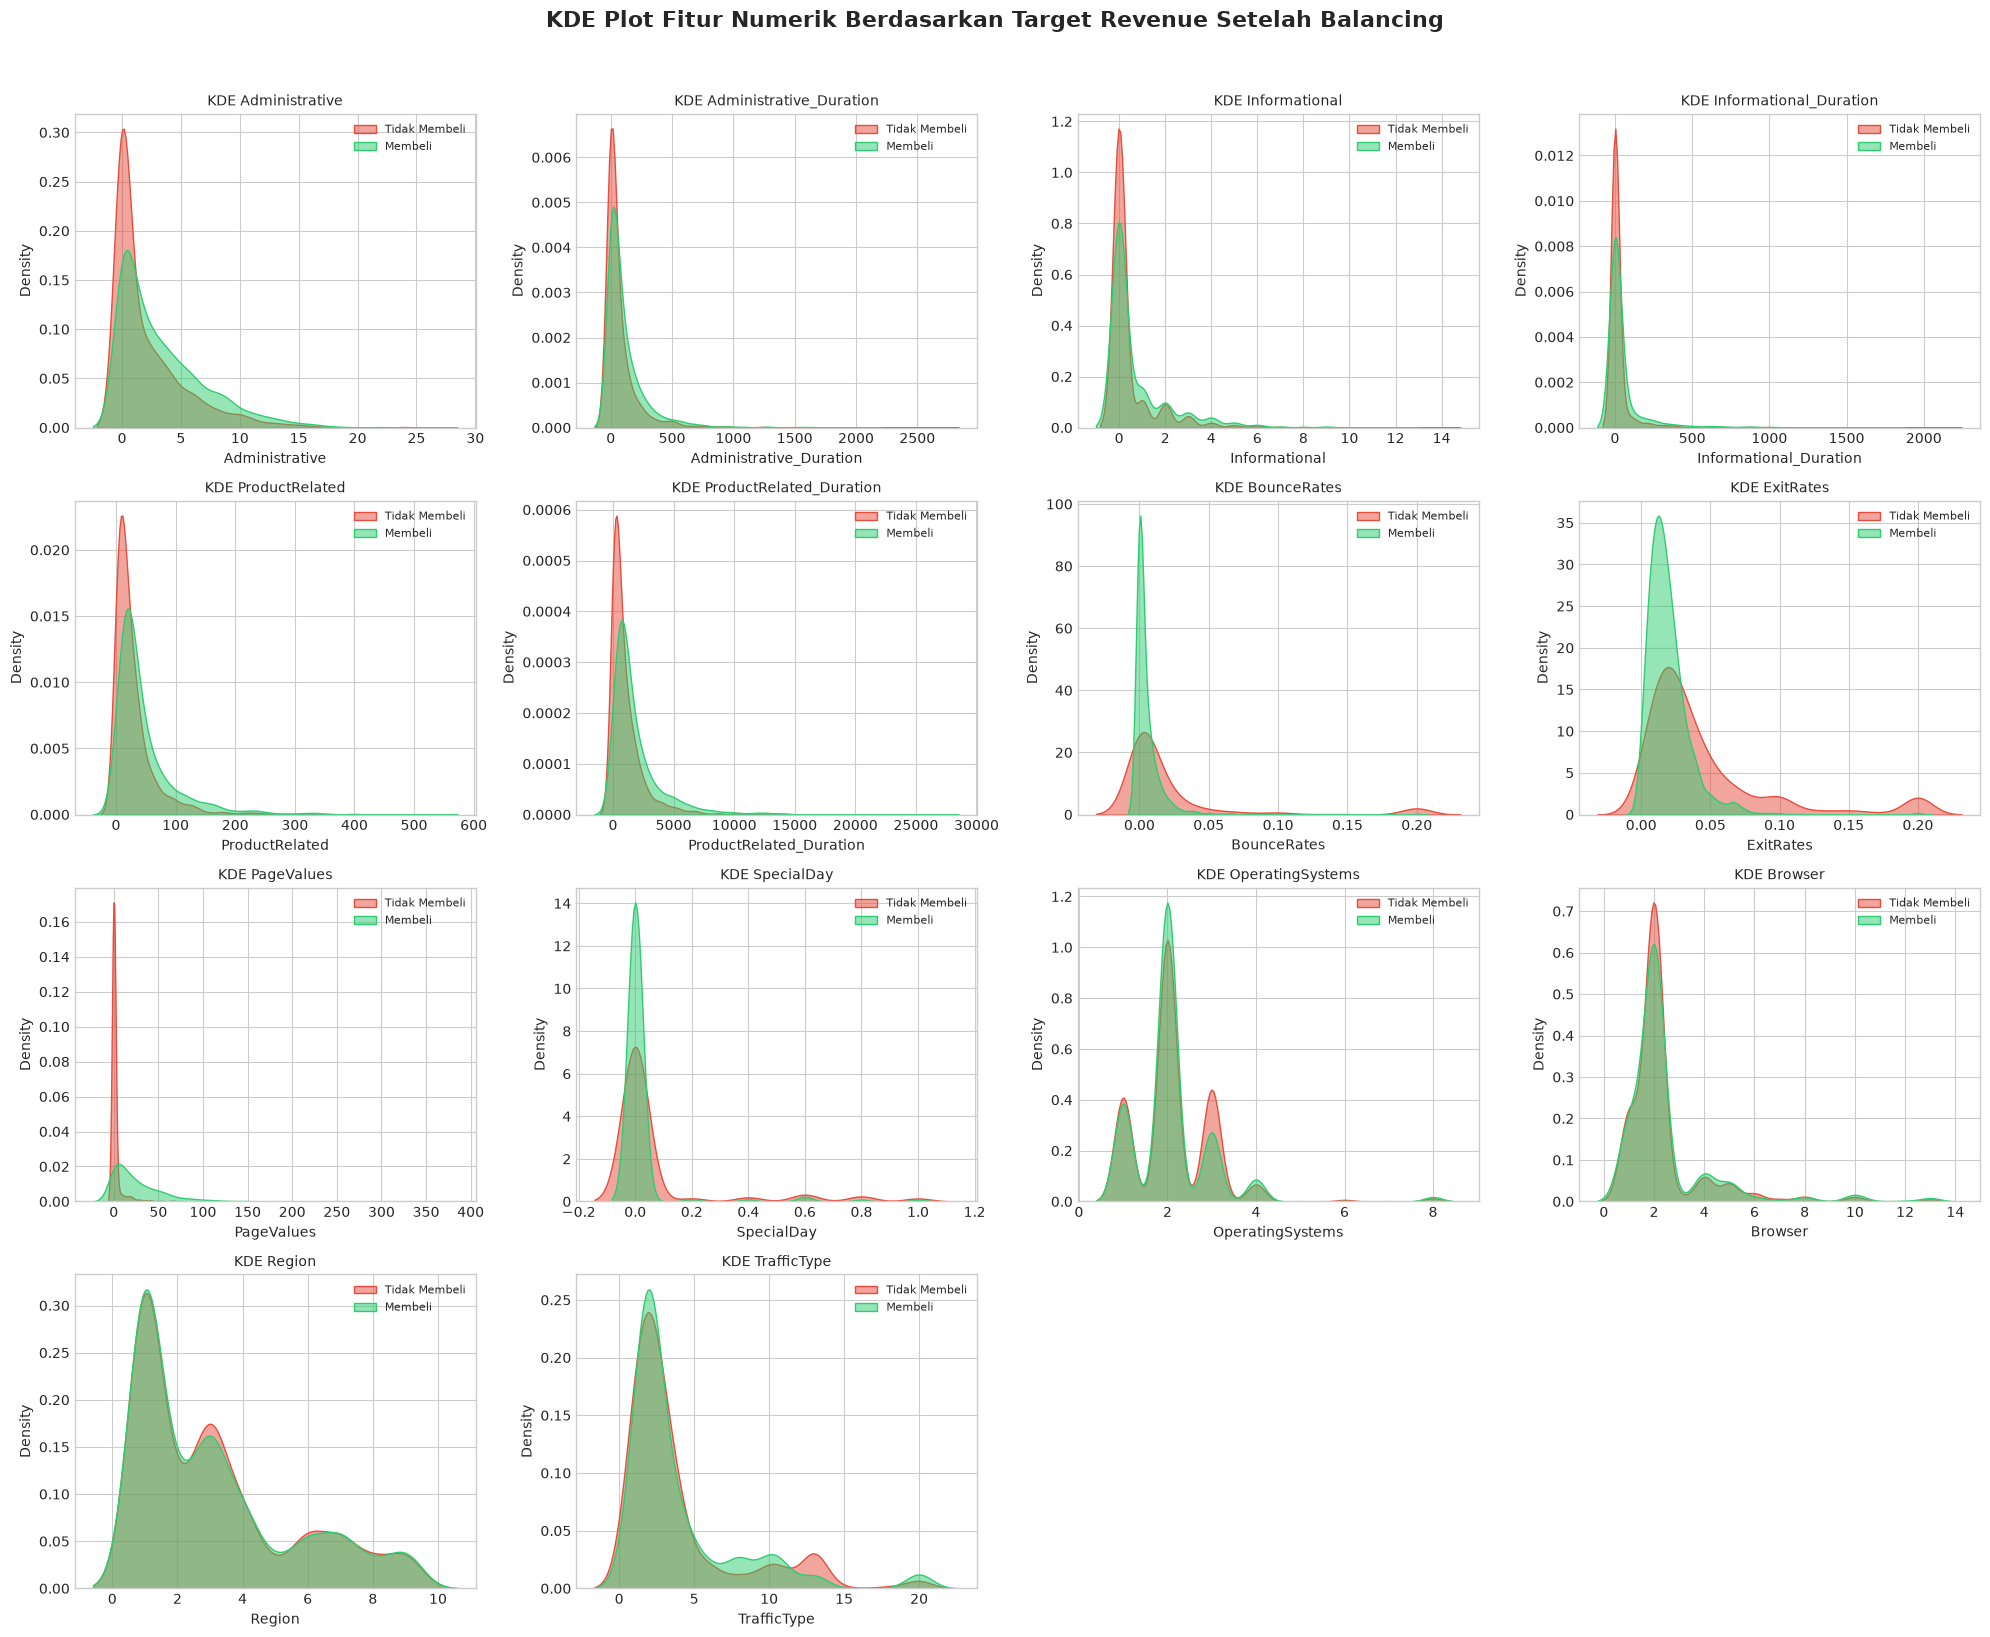

KDE plot setelah balancing disimpan di: ../Outputs/eda_balanced_kde_plots.png

9b.8 Perbandingan Distribusi Sebelum dan Sesudah Balancing


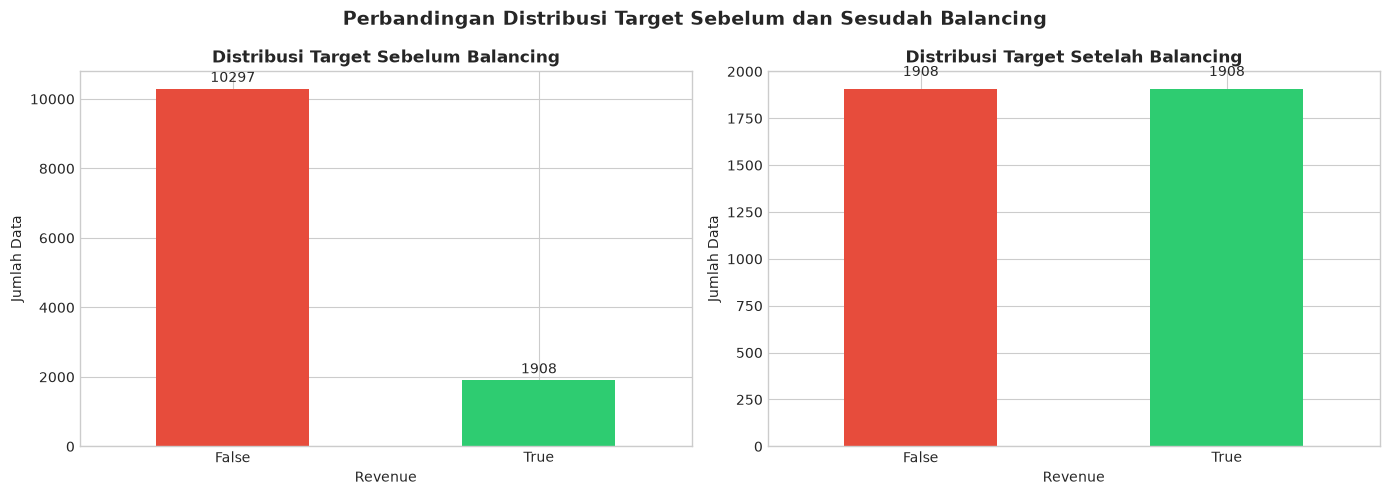

Perbandingan distribusi sebelum dan sesudah balancing disimpan di: ../Outputs/eda_balanced_comparison.png

EDA Setelah Balancing Complete - Semua visualisasi disimpan di folder 'Outputs'


In [11]:

# ============================
# 9b. EDA Setelah Balancing
# ============================

# 9b.1 Distribusi Fitur Numerik Setelah Balancing
print("=" * 50)
print("9b.1 Distribusi Fitur Numerik Setelah Balancing")
print("=" * 50)

numeric_cols_balanced = df_balanced.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols_grid = min(4, len(numeric_cols_balanced))
n_rows_grid = (len(numeric_cols_balanced) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

palette = sns.color_palette("husl", len(numeric_cols_balanced))
for idx, col in enumerate(numeric_cols_balanced):
    sns.histplot(data=df_balanced, x=col, kde=True, ax=axes[idx], color=palette[idx])
    axes[idx].set_title(f'Distribusi {col}', fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

for idx in range(len(numeric_cols_balanced), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik Setelah Balancing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_balanced_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram distribusi fitur numerik setelah balancing disimpan di: ../Outputs/eda_balanced_numerical_distributions.png")

# 9b.2 Box Plot Fitur Numerik Berdasarkan Target Setelah Balancing
print("\n" + "=" * 50)
print("9b.2 Box Plot Fitur Numerik Berdasarkan Target Setelah Balancing")
print("=" * 50)

n_cols_grid = min(4, len(numeric_cols_balanced))
n_rows_grid = (len(numeric_cols_balanced) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_balanced):
    sns.boxplot(data=df_balanced, x='Revenue', y=col, ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
    axes[idx].set_title(f'Box Plot {col} vs Revenue', fontsize=10)
    axes[idx].set_xlabel('Revenue')
    axes[idx].set_ylabel(col)

for idx in range(len(numeric_cols_balanced), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Box Plot Fitur Numerik Berdasarkan Target Revenue Setelah Balancing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_balanced_boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot setelah balancing disimpan di: ../Outputs/eda_balanced_boxplots_by_target.png")

# 9b.3 Distribusi Fitur Kategorikal Setelah Balancing
print("\n" + "=" * 50)
print("9b.3 Distribusi Fitur Kategorikal Setelah Balancing")
print("=" * 50)

categorical_cols_balanced = df_balanced.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_cols_balanced = [col for col in categorical_cols_balanced if col != 'Revenue']

if len(categorical_cols_balanced) > 0:
    n_cats = len(categorical_cols_balanced)
    n_rows = (n_cats + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    colors = sns.color_palette("Set2", n_cats)
    
    for idx, col in enumerate(categorical_cols_balanced):
        value_counts = df_balanced[col].value_counts()
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=axes[idx], palette=[colors[idx]])
        axes[idx].set_title(f'Distribusi {col}', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Jumlah')
        axes[idx].tick_params(axis='x', rotation=45)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)
    
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Distribusi Fitur Kategorikal Setelah Balancing', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_balanced_categorical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Distribusi kategorikal setelah balancing disimpan di: ../Outputs/eda_balanced_categorical_distributions.png")

# 9b.4 Count Plot Fitur Kategorikal Berdasarkan Target Setelah Balancing
print("\n" + "=" * 50)
print("9b.4 Count Plot Fitur Kategorikal Berdasarkan Target Setelah Balancing")
print("=" * 50)

if len(categorical_cols_balanced) > 0:
    n_cats = len(categorical_cols_balanced)
    n_rows = (n_cats + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols_balanced):
        sns.countplot(data=df_balanced, x=col, hue='Revenue', ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
        axes[idx].set_title(f'{col} vs Revenue', fontsize=12)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Jumlah')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='Revenue', labels=['Tidak Membeli', 'Membeli'])
    
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Fitur Kategorikal Berdasarkan Target Revenue Setelah Balancing', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_balanced_categorical_by_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Count plot kategorikal setelah balancing disimpan di: ../Outputs/eda_balanced_categorical_by_target.png")

# 9b.5 Correlation Heatmap Setelah Balancing - Top 5 Fitur
print("\n" + "=" * 50)
print("9b.5 Correlation Heatmap Setelah Balancing - Top 5 Fitur")
print("=" * 50)

df_numeric_balanced = df_balanced.select_dtypes(include=['int64', 'float64'])
correlation_matrix_balanced = df_numeric_balanced.corr()

# Ambil top 5 fitur dengan korelasi tertinggi terhadap Revenue
if 'Revenue' in correlation_matrix_balanced.columns:
    target_corr = correlation_matrix_balanced['Revenue'].drop('Revenue').abs().sort_values(ascending=False)
    top_5_features = target_corr.head(5).index.tolist()
    top_5_features.append('Revenue')
    correlation_top5 = correlation_matrix_balanced.loc[top_5_features, top_5_features]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_top5,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Korelasi"},
        annot_kws={"size": 10}
    )
    plt.title('Top 5 Korelasi Fitur dengan Target Revenue Setelah Balancing', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../Outputs/eda_balanced_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Top 5 correlation heatmap setelah balancing disimpan di: ../Outputs/eda_balanced_correlation_heatmap.png")
    print(f"Top 5 fitur: {top_5_features[:-1]}")

# 9b.6 Korelasi Fitur dengan Target Setelah Balancing
print("\n" + "=" * 50)
print("9b.6 Korelasi Fitur dengan Target Setelah Balancing")
print("=" * 50)

if 'Revenue' in correlation_matrix_balanced.columns:
    target_corr_balanced = correlation_matrix_balanced['Revenue'].drop('Revenue').sort_values()
    
    plt.figure(figsize=(12, 8))
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr_balanced.values]
    sns.barplot(x=target_corr_balanced.values, y=target_corr_balanced.index, palette=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.title('Korelasi Fitur dengan Target Revenue Setelah Balancing', fontsize=14, fontweight='bold')
    plt.xlabel('Korelasi')
    plt.ylabel('Fitur')
    plt.tight_layout()
    plt.savefig('../Outputs/eda_balanced_target_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Korelasi dengan target setelah balancing disimpan di: ../Outputs/eda_balanced_target_correlation.png")

# 9b.7 KDE Plot Fitur Numerik Berdasarkan Target Setelah Balancing
print("\n" + "=" * 50)
print("9b.7 KDE Plot Fitur Numerik Berdasarkan Target Setelah Balancing")
print("=" * 50)

n_cols_grid = min(4, len(numeric_cols_balanced))
n_rows_grid = (len(numeric_cols_balanced) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
if n_rows_grid * n_cols_grid == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_balanced):
    sns.kdeplot(data=df_balanced[df_balanced['Revenue'] == False], x=col, ax=axes[idx], color='#e74c3c', label='Tidak Membeli', fill=True, alpha=0.5)
    sns.kdeplot(data=df_balanced[df_balanced['Revenue'] == True], x=col, ax=axes[idx], color='#2ecc71', label='Membeli', fill=True, alpha=0.5)
    axes[idx].set_title(f'KDE {col}', fontsize=10)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

for idx in range(len(numeric_cols_balanced), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('KDE Plot Fitur Numerik Berdasarkan Target Revenue Setelah Balancing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/eda_balanced_kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("KDE plot setelah balancing disimpan di: ../Outputs/eda_balanced_kde_plots.png")

# 9b.8 Perbandingan Distribusi Sebelum dan Sesudah Balancing
print("\n" + "=" * 50)
print("9b.8 Perbandingan Distribusi Sebelum dan Sesudah Balancing")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum balancing
df_clean['Revenue'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Target Sebelum Balancing', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Jumlah Data')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df_clean['Revenue'].value_counts().values):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=10)

# Sesudah balancing
df_balanced['Revenue'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Distribusi Target Setelah Balancing', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Jumlah Data')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(df_balanced['Revenue'].value_counts().values):
    axes[1].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Distribusi Target Sebelum dan Sesudah Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/eda_balanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Perbandingan distribusi sebelum dan sesudah balancing disimpan di: ../Outputs/eda_balanced_comparison.png")

print("\n" + "=" * 50)
print("EDA Setelah Balancing Complete - Semua visualisasi disimpan di folder 'Outputs'")
print("=" * 50)

## 10. Memisahkan Fitur dan Target

Pada tahap ini dataset dipisahkan menjadi fitur input dan target output.

- `X` berisi seluruh fitur yang digunakan untuk melakukan prediksi.
- `y` berisi target yang akan diprediksi, yaitu kolom `Revenue`.

Kolom `Revenue` diubah menjadi integer:
- `False` menjadi 0
- `True` menjadi 1

In [12]:

# ============================
# 10. Memisahkan Fitur dan Target
# ============================

X = df_balanced.drop(columns=['Revenue'])
y = df_balanced['Revenue'].astype(int)

print("Jumlah data fitur:", X.shape)
print("Jumlah data target:", y.shape)

print("\nContoh fitur:")
print(X.head())

print("\nContoh target:")
print(y.head())

Jumlah data fitur: (3816, 17)
Jumlah data target: (3816,)

Contoh fitur:
   Administrative  Administrative_Duration  Informational  \
0               4                92.750000              0   
1               6                96.857143              0   
2               4               176.913333              1   
3               2               152.833333              0   
4               2                50.500000              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               9               108.250000   
1                     0.0              28               672.545238   
2                    40.8              72              1548.194444   
3                     0.0              20               791.666667   
4                     0.0              70              2802.116667   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0     0.000000   0.021429    0.000000         0.0   Nov       

## 11. Menentukan Fitur Numerik dan Kategorikal

Dataset memiliki dua jenis fitur, yaitu fitur numerik dan fitur kategorikal.

Fitur numerik akan diproses menggunakan `StandardScaler`, sedangkan fitur kategorikal akan diproses menggunakan `OneHotEncoder`.

In [13]:

# ============================
# 11. Menentukan Fitur Numerik dan Kategorikal
# ============================

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Fitur numerik:")
print(numeric_features)

print("\nFitur kategorikal:")
print(categorical_features)

Fitur numerik:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Fitur kategorikal:
['Month', 'VisitorType', 'Weekend']


## 12. Preprocessing Data

Preprocessing dilakukan agar data siap digunakan oleh model machine learning.

Proses yang dilakukan:
1. `StandardScaler` untuk menstandarkan skala fitur numerik.
2. `OneHotEncoder` untuk mengubah fitur kategorikal menjadi bentuk numerik.
3. `ColumnTransformer` untuk menggabungkan preprocessing numerik dan kategorikal dalam satu proses.

In [14]:

# ============================
# 12. Preprocessing Data
# ============================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing berhasil disiapkan.")

Preprocessing berhasil disiapkan.


## 13. Train-Test Split

Dataset dibagi menjadi data training dan data testing.

- Data training digunakan untuk melatih model.
- Data testing digunakan untuk menguji performa model terhadap data yang belum pernah dilihat sebelumnya.

Pada proyek ini digunakan rasio 80:20, yaitu:
- 80% data training
- 20% data testing

Parameter `stratify=y` digunakan agar distribusi target pada data training dan testing tetap seimbang.

In [15]:

# ============================
# 13. Train-Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

print("\nDistribusi target pada data training:")
print(y_train.value_counts())

print("\nDistribusi target pada data testing:")
print(y_test.value_counts())

Ukuran X_train: (3052, 17)
Ukuran X_test : (764, 17)
Ukuran y_train: (3052,)
Ukuran y_test : (764,)

Distribusi target pada data training:
Revenue
0    1526
1    1526
Name: count, dtype: int64

Distribusi target pada data testing:
Revenue
0    382
1    382
Name: count, dtype: int64


## 14. Menyiapkan Algoritma Machine Learning

Pada tahap ini disiapkan beberapa algoritma machine learning untuk dibandingkan performanya.

Algoritma yang digunakan:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost
6. K-Nearest Neighbors
7. Support Vector Machine

SVM ditambahkan karena algoritma ini cocok untuk klasifikasi biner. SVM bekerja dengan mencari batas pemisah terbaik antara dua kelas.

In [16]:

# ============================
# 14. Menyiapkan Algoritma Machine Learning
# ============================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

print("Daftar model yang akan digunakan:")
for model_name in models.keys():
    print("-", model_name)

Daftar model yang akan digunakan:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- KNN
- SVM


## 15. Training dan Evaluasi Semua Model

Setiap model dilatih menggunakan data training dan diuji menggunakan data testing.

Model dievaluasi menggunakan beberapa metrik:

- Accuracy: mengukur jumlah prediksi benar secara keseluruhan.
- Precision: mengukur ketepatan model saat memprediksi kelas membeli.
- Recall: mengukur kemampuan model menemukan data yang benar-benar membeli.
- F1-Score: gabungan dari precision dan recall.
- ROC-AUC: mengukur kemampuan model membedakan kelas membeli dan tidak membeli.

Model terbaik dipilih berdasarkan nilai F1-Score tertinggi.

In [17]:

# ============================
# 15. Training dan Evaluasi Semua Model
# ============================

results = []
trained_models = {}

for name, model in models.items():
    print(f"Melatih model: {name}")

    # Membuat pipeline yang berisi preprocessing dan model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Melatih model
    pipeline.fit(X_train, y_train)

    # Melakukan prediksi
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Menyimpan hasil evaluasi
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

    # Menyimpan model yang sudah dilatih
    trained_models[name] = pipeline

# Membuat tabel hasil evaluasi
results_df = pd.DataFrame(results)

# Mengurutkan berdasarkan F1-Score tertinggi
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print(results_df)

Melatih model: Logistic Regression
Melatih model: Decision Tree
Melatih model: Random Forest
Melatih model: Gradient Boosting
Melatih model: XGBoost
Melatih model: KNN
Melatih model: SVM
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0    Gradient Boosting  0.837696   0.839474  0.835079  0.837270  0.922963
1              XGBoost  0.831152   0.830287  0.832461  0.831373  0.917231
2        Random Forest  0.829843   0.833333  0.824607  0.828947  0.917724
3  Logistic Regression  0.808901   0.829609  0.777487  0.802703  0.890806
4                  SVM  0.808901   0.837143  0.767016  0.800546  0.889826
5        Decision Tree  0.785340   0.791444  0.774869  0.783069  0.785340
6                  KNN  0.735602   0.733161  0.740838  0.736979  0.818279


## 16. Visualisasi Perbandingan Model

Visualisasi dilakukan untuk membandingkan performa setiap model berdasarkan nilai F1-Score. F1-Score digunakan karena metrik ini mempertimbangkan keseimbangan antara precision dan recall.

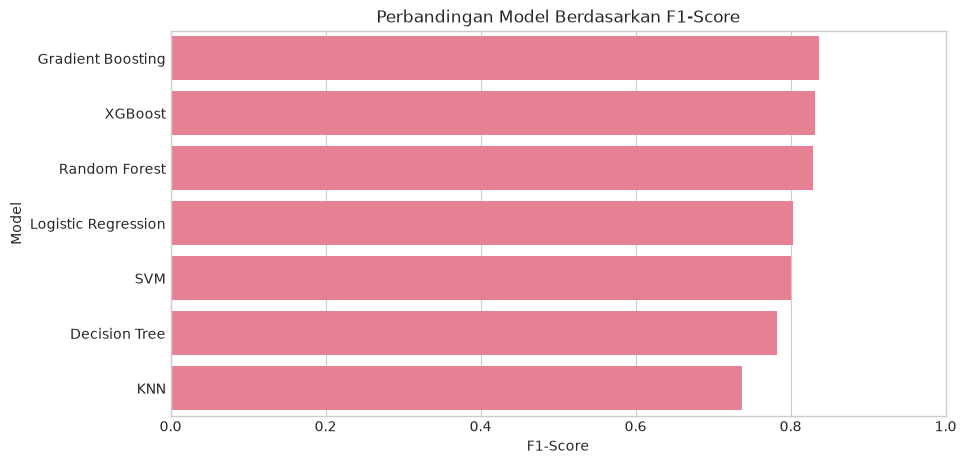

In [18]:

# ============================
# 16. Visualisasi Perbandingan Model
# ============================

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='F1-Score', y='Model')
plt.title('Perbandingan Model Berdasarkan F1-Score')
plt.xlabel('F1-Score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

## 17. Menentukan Model Terbaik

Model terbaik ditentukan berdasarkan nilai F1-Score tertinggi dari tabel evaluasi. Model terbaik ini kemudian digunakan untuk evaluasi lebih detail dan disimpan agar dapat digunakan pada prototype aplikasi.

In [19]:

# ============================
# 17. Menentukan Model Terbaik
# ============================

best_model_name = results_df.loc[0, 'Model']
best_pipeline = trained_models[best_model_name]

print("Model terbaik berdasarkan F1-Score adalah:", best_model_name)

print(results_df.head(1))

Model terbaik berdasarkan F1-Score adalah: Gradient Boosting
               Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Gradient Boosting  0.837696   0.839474  0.835079   0.83727  0.922963


## 18. Evaluasi Detail Model Terbaik

Setelah model terbaik diperoleh, dilakukan evaluasi lebih detail menggunakan classification report. Evaluasi ini menampilkan precision, recall, dan F1-Score untuk masing-masing kelas.

In [20]:

# ============================
# 18. Evaluasi Detail Model Terbaik
# ============================

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print("Evaluasi Model Terbaik:", best_model_name)
print("=" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best, zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_best, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_best))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Tidak Membeli', 'Membeli'],
    zero_division=0
))

Evaluasi Model Terbaik: Gradient Boosting
Accuracy : 0.837696335078534
Precision: 0.8394736842105263
Recall   : 0.8350785340314136
F1-Score : 0.8372703412073491
ROC-AUC  : 0.922963323373811

Classification Report:
               precision    recall  f1-score   support

Tidak Membeli       0.84      0.84      0.84       382
      Membeli       0.84      0.84      0.84       382

     accuracy                           0.84       764
    macro avg       0.84      0.84      0.84       764
 weighted avg       0.84      0.84      0.84       764



## 19. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah dari model.

Keterangan:
- True Negative: Tidak membeli dan diprediksi tidak membeli.
- False Positive: Tidak membeli tetapi diprediksi membeli.
- False Negative: Membeli tetapi diprediksi tidak membeli.
- True Positive: Membeli dan diprediksi membeli.

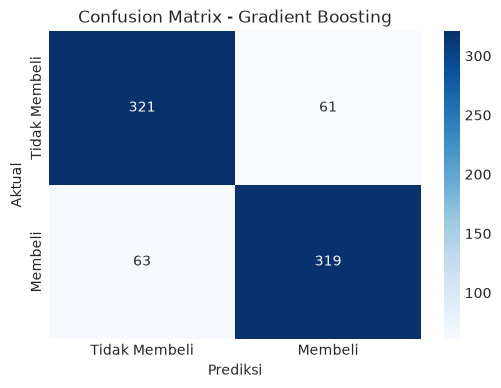

In [21]:

# ============================
# 19. Confusion Matrix
# ============================

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Membeli', 'Membeli'],
    yticklabels=['Tidak Membeli', 'Membeli']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 19b. Pie Chart Prediksi Benar dan Salah

Pie chart menampilkan persentase prediksi benar dan salah dari model terbaik.

Prediksi Benar : 640 (83.77%)
Prediksi Salah : 124 (16.23%)


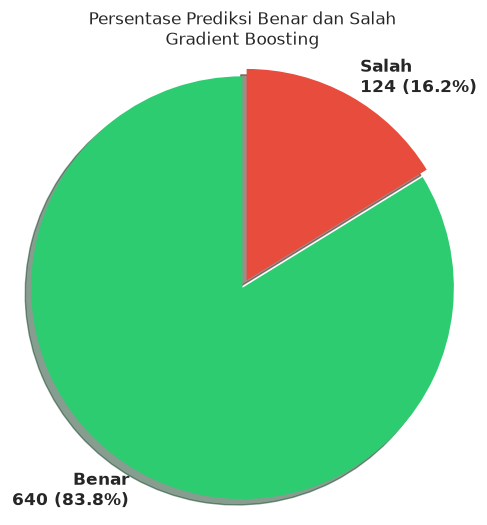

In [22]:

# ============================
# 19b. Pie Chart Prediksi Benar dan Salah
# ============================

cm = confusion_matrix(y_test, y_pred_best)

# Menghitung jumlah prediksi benar dan salah
tn, fp, fn, tp = cm.ravel()
prediksi_benar = tp + tn
prediksi_salah = fp + fn
total = prediksi_benar + prediksi_salah

persen_benar = (prediksi_benar / total) * 100
persen_salah = (prediksi_salah / total) * 100

print(f"Prediksi Benar : {prediksi_benar} ({persen_benar:.2f}%)")
print(f"Prediksi Salah : {prediksi_salah} ({persen_salah:.2f}%)")

# Membuat pie chart
labels = [f'Benar\n{prediksi_benar} ({persen_benar:.1f}%)', f'Salah\n{prediksi_salah} ({persen_salah:.1f}%)']
sizes = [prediksi_benar, prediksi_salah]
colors = ['#2ecc71', '#e74c3c']
explode = (0.02, 0.02)

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='',
    shadow=True,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.title(f'Persentase Prediksi Benar dan Salah\n{best_model_name}')
plt.axis('equal')
plt.show()

## 20. Contoh Prediksi Data Baru

Pada tahap ini dilakukan simulasi prediksi menggunakan salah satu data dari data testing. Tujuannya untuk memastikan model dapat digunakan untuk memprediksi data baru.

In [23]:

# ============================
# 20. Contoh Prediksi Data Baru
# ============================

# Mengambil 1 data dari data testing
sample_data = X_test.iloc[[0]]

# Melakukan prediksi
sample_prediction = best_pipeline.predict(sample_data)[0]
sample_probability = best_pipeline.predict_proba(sample_data)[0][1]

# Mengubah hasil prediksi menjadi label
if sample_prediction == 1:
    hasil_prediksi = "Membeli"
else:
    hasil_prediksi = "Tidak Membeli"

print("Contoh data yang diprediksi:")
print(sample_data)

print("\nHasil prediksi:", hasil_prediksi)
print("Probabilitas membeli:", round(sample_probability * 100, 2), "%")

Contoh data yang diprediksi:
      Administrative  Administrative_Duration  Informational  \
1169               0                      0.0              0   

      Informational_Duration  ProductRelated  ProductRelated_Duration  \
1169                     0.0               1                      0.0   

      BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
1169          0.2        0.2         0.0         0.2   May                 1   

      Browser  Region  TrafficType        VisitorType  Weekend  
1169        1       4            3  Returning_Visitor    False  

Hasil prediksi: Tidak Membeli
Probabilitas membeli: 0.86 %


## 21. Menyimpan Model

Model terbaik disimpan dalam format `.pkl` menggunakan library Joblib. File model ini nantinya dapat digunakan kembali tanpa perlu melakukan training ulang, misalnya untuk pembuatan prototype UI menggunakan Streamlit atau Gradio.

In [24]:

# ============================
# 21. Menyimpan Model
# ============================

nama_file_model = '../Models/model_prediksi_pembelian_ecommerce.pkl'

joblib.dump(best_pipeline, nama_file_model)

print("Model berhasil disimpan dengan nama:", nama_file_model)

Model berhasil disimpan dengan nama: ../Models/model_prediksi_pembelian_ecommerce.pkl
